In [1]:
_MERKZETTEL = {}


def merke(schluessel, wert):
    """Haelt ein Ergebnis fuer den Fliesstext fest und gibt es zurueck."""
    _MERKZETTEL[schluessel] = wert
    return wert

# Anomalieerkennung: Was ist gestern schiefgelaufen?

**Verfahren:** Anomalieerkennung (unüberwacht — gesucht wird die Ausnahme, nicht die Regel)  |  **Geschäftsfrage:** Drei Fragen, drei Zeitpunkte: Welches Rad ist JETZT überfällig, welche abgeschlossenen Vorgänge verdienen heute früh einen Blick, und welche Station stand gestern still?

[![In Colab öffnen](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/swrobuts/velocity-fallstudie/blob/main/analytics/notebooks/06_Anomalieerkennung_Auffaellige_Vorgaenge.ipynb)

---

## Wie dieses Notebook aufgebaut ist

Es folgt **CRISP-DM** (*Cross-Industry Standard Process for Data Mining*) — dem
Vorgehensmodell, das seit 1999 der De-facto-Standard für Analyseprojekte ist. Sechs
Phasen, und zwar als **Kreislauf**, nicht als Treppe:

| | Phase | Leitfrage |
|---|---|---|
| 1 | Business Understanding | Was ist die Geschäftsfrage — und woran messen wir Erfolg? |
| 2 | Data Understanding | Welche Daten haben wir, und taugen sie für diese Frage? |
| 3 | Data Preparation | Wie wird aus Rohdaten eine Tabelle, mit der ein Verfahren rechnen kann? |
| 4 | Modeling | Welches Verfahren, welche Einstellungen, wie geprüft? |
| 5 | Evaluation | Ist das Modell gut genug für die Geschäftsfrage aus Phase 1? |
| 6 | Deployment | Wie kommt das Modell in den Betrieb — und was passiert danach? |

**Der Pfeil von Phase 5 zurück auf Phase 1 ist kein Schönheitsfehler des Diagramms.**
Er ist die wichtigste Linie darin. In der Praxis stellt sich in der Evaluation regelmäßig
heraus, dass die Frage aus Phase 1 anders gestellt werden muss oder dass Daten fehlen,
an die in Phase 2 niemand gedacht hat. Ein Analyseprojekt, das die sechs Phasen genau
einmal von oben nach unten durchläuft, ist die Ausnahme — nicht die Regel.

Am Ende dieses Notebooks steht deshalb ausdrücklich die Frage, **was eine zweite Runde
anders machen würde**.

> **Lehrdatensatz.** Fahrten, Langzeitvorgänge und Stationsstörungen in dieser Fallstudie
> sind **synthetisch erzeugt** und didaktisch verstärkt: Die langen Fahrten und die
> Störungstage wurden absichtlich als Anker eingebaut, damit sich überhaupt etwas messen
> lässt. Alle Trefferquoten in diesem Notebook zeigen deshalb **das Verhalten der
> Verfahren**, nicht die Güte eines Betriebssystems. Für eine reale Freigabe zählt keine
> einzige Zahl von hier.

## Das Verfahren, das nach dem Gegenteil sucht

Alle bisherigen Notebooks haben **Muster** gesucht. Dieses sucht die **Abweichung vom
Muster** — und dreht damit die übliche Frage um:

| | Frage |
|---|---|
| Notebook 1–2 | Was ist typisch für diesen Fall? |
| Notebook 3 | Welche typischen Gruppen gibt es? |
| Notebook 5 | Welche typischen Zusammenhänge gibt es? |
| **Notebook 6** | **Was passt in keines dieser Muster?** |

Das klingt einfacher, als es ist. Denn die eigentliche Schwierigkeit liegt nicht darin,
Ausreißer zu finden — das erledigt jedes Verfahren in drei Zeilen. Sie liegt in der
Frage danach:

> **Auffällig ist nicht dasselbe wie problematisch.**

Ein Notebook, das tausend Auffälligkeiten ausspuckt, hat den Betrieb nicht entlastet,
sondern beschäftigt. Deshalb steht hier — mehr noch als in den anderen — die
Priorisierung im Mittelpunkt.

**Und dieses Notebook enthält ein negatives Ergebnis.** Eine der beiden Aufgaben, die wir
uns in Phase 1 stellen, lässt sich mit diesen Daten **nicht** lösen. Warum das so ist und
was daraus folgt, ist der lehrreichste Teil — im Berufsleben ist ein sauber begründetes
„geht nicht“ mehr wert als ein geschöntes „geht doch“.

---

**1. Business** · 2. Data · 3. Data · 4. Modeling · 5. Evaluation · 6. Deployment

# Phase 1 von 6 — Business Understanding

> **Leitfrage:** Was ist die Geschäftsfrage — und woran messen wir Erfolg?
>
> **In diesem Notebook heißt das:** Der Betrieb hat morgens eine halbe Stunde. Was soll er sich ansehen?

### Die Ausgangslage

Im Betriebsbüro sitzt morgens jemand, der den Vortag durchsieht. Heute geschieht das
stichprobenhaft: Man scrollt durch die Liste und schaut, was ins Auge fällt. Bei rund
**einigen Dutzend Fahrten am Tag** geht das noch; bei einem wachsenden Netz nicht mehr.

Gesucht ist eine **kurze Tagesliste**, die einen menschlichen Blick verdient. Wie kurz,
wird gleich ausgerechnet — nicht gesetzt.

### Drei Produkte, nicht eine Liste

Die naheliegende Fassung dieser Aufgabe lautet: „eine Liste mit den auffälligsten
Vorgängen von gestern". Sie ist falsch, und der Fehler ist nicht offensichtlich — er liegt
im **Zeitpunkt**.

Ein Rad, das seit vierzehn Stunden unterwegs ist, soll **jetzt** gesucht werden, nicht
morgen früh. Eine ungewöhnlich teure Fahrt von gestern kann warten. Und eine stillstehende
Station betrifft überhaupt nicht dieselbe Beobachtungseinheit — dort ist ein *Stationstag*
der Fall, keine Fahrt.

Wir trennen deshalb von Anfang an drei Produkte:

| | Produkt | Wann entschieden wird | Datengrundlage | Wer handelt |
|---|---|---|---|---|
| **A1** | **offene Rückgaben** | laufend, in Echtzeit | Vorgänge, die **noch offen** sind | Betrieb kontaktiert und sucht |
| **A2** | **auffällige abgeschlossene Fahrten** | morgens, über den Vortag | Fahrten, die **bereits beendet** sind | Betriebsbüro prüft am Schreibtisch |
| **B** | **auffällige Stationstage** | morgens, über den Vortag | Stationstage | Technik prüft das Terminal |

> **Warum diese Trennung der wichtigste Schritt des ganzen Notebooks ist.** Eine frühere
> Fassung hat A1 und A2 in eine Liste geworfen und dabei die Maßnahme „Rad bergen, bevor
> es verschwindet" mit **abgeschlossenen** Fahrten begründet. Bei einer abgeschlossenen
> Fahrt ist das Rad längst zurück — da ist nichts mehr zu bergen. Die Liste war richtig
> gerechnet und für ihren angegebenen Zweck nutzlos.
>
> **Wer den Entscheidungszeitpunkt nicht festlegt, baut ein Produkt, das es nicht geben
> kann.**

### Was ein Fund wert ist, und was ein Fehlalarm kostet

| | | Kosten |
|---|---|---|
| **gefundene echte Auffälligkeit** | Rad wird geborgen, bevor es verschwindet | **Nutzen 120 €** |
| **Fehlalarm** | jemand sieht sich einen Vorgang an, der in Ordnung war | **6 €** (fünf Minuten) |
| **übersehene Auffälligkeit** | Rad bleibt liegen, wird gestohlen oder beschädigt | **Verlust 120 €** |

**Ab einer Trefferquote von rund 5 % rechnet sich die Liste bereits** — der eine Fund
trägt die neunzehn Fehlalarme. Das ist eine ungewöhnlich niedrige Schwelle, und sie ist
typisch für Anomalieerkennung: Man darf sich viel Ungenauigkeit leisten, solange die Fälle
selten und die Funde wertvoll sind.

> **Wie lang darf die Liste sein?** Auch diese Zahl wird gerechnet, nicht gesetzt. Das
> Betriebsbüro hat morgens eine halbe Stunde, eine Prüfung dauert fünf Minuten — das sind
> **sechs Fälle**, nicht zehn. Eine frühere Fassung dieses Notebooks nannte im selben
> Absatz „eine halbe Stunde" und „zehn Plätze"; zehn Prüfungen brauchen aber 50 Minuten.
> Die Listenlänge wird unten aus Zeitbudget und Prüfdauer abgeleitet, damit sich der
> Widerspruch nicht wiederholen kann.

> **Diese 5 % sind aber nicht unser Erfolgskriterium.** Sie sind die Grenze, ab der die
> Liste kein Geld verbrennt. Eine Liste, bei der neunzehn von zwanzig Einträgen unnötig
> sind, wird nach zwei Wochen niemand mehr öffnen — und dann ist der rechnerische Nutzen
> gleich null. Wir setzen deshalb **20 %** an: jeder fünfte Eintrag muss tragen.
>
> Der Unterschied zwischen „rechnet sich" und „wird benutzt" ist genau der Grund, warum
> Erfolgskriterien nicht aus einer Kostenrechnung allein folgen.

### Erfolgskriterien — je Produkt eigene, weil es drei Produkte sind

| Produkt | Kriterium | Schwelle | Prüfbar? |
|---|---|---|---|
| **A1** offene Rückgaben | jeder offene Vorgang über der Schwelle wird gemeldet, **bevor** er endet | Vollständigkeit | **nur logisch** — Label und Regel benutzen dieselbe 8-Stunden-Grenze; betrieblich nicht prüfbar |
| **A2** auffällige Fahrten | Liste ≤ Kapazität, jede Zeile mit Begründung | Kapazität und Nachvollziehbarkeit | ja |
| **A2** auffällige Fahrten | Trefferquote | **nicht festlegbar** | **nein** — siehe unten |
| **B** Stationstage | mindestens jede fünfte gemeldete **Störungsepisode** ist echt | 20 % | ja, gegen `stationsstoerung.csv` |

> **Für A2 gibt es bewusst kein Trefferkriterium, und das ist keine Nachlässigkeit.** Eine
> Trefferquote braucht ein Label. Für „unbekannte Auffälligkeiten" gibt es per Definition
> keines — wer eines hätte, wüsste schon, wonach er sucht. Was wir haben, ist eine
> **Teilwahrheit** (Fahrten über acht Stunden), und die misst nur, wie gut das Modell eine
> Regel nachbaut, die wir ohnehin haben.
>
> Der einzige ehrliche Weg für A2 heißt **Schattenbetrieb**: Die Liste läuft mit, jemand
> beurteilt jede Zeile, und **danach** — nicht vorher — lässt sich eine Trefferquote
> nennen. Bis dahin ist A2 eine Hypothesenliste, kein Erkennungssystem.

> **Und ein Kriterium, das hier fehlt und in einer zweiten Runde dazugehört:** eine
> Zufallsstichprobe aus den **nicht** gemeldeten Vorgängen. Ohne sie erfährt man nie, wie
> viele Probleme die Liste übersehen hat — man sieht nur die, die sie zeigt.

---

1. Business · **2. Data** · 3. Data · 4. Modeling · 5. Evaluation · 6. Deployment

# Phase 2 von 6 — Data Understanding

> **Leitfrage:** Welche Daten haben wir, und taugen sie für diese Frage?
>
> **In diesem Notebook heißt das:** Bevor irgendein Verfahren läuft: Wie sieht normal überhaupt aus?

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Die Adresse zeigt auf den Zweig 'main' - der sich aendern kann. Fuer eine
# Auswertung, die spaeter exakt reproduzierbar sein muss, gehoert hier ein
# fester Commit-Hash statt 'main' hinein.
BASIS = os.environ.get("VELO_BASIS",
    "https://raw.githubusercontent.com/swrobuts/velocity-fallstudie/07d1b5df58c690044b19ec9776903c944972928f/analytics/")
pd.set_option("display.width", 160)

# Die Zahlen aus Phase 1 - hier ausgedruckt, damit Text und Rechnung nicht
# auseinanderlaufen koennen. Beide Schwellen werden ABGELEITET, nicht gesetzt.
NUTZEN_FUND = 120.0        # geborgenes Rad statt Verlust
# Acht Stunden. Die Zahl steht EINMAL - sie definiert die Teilwahrheit,
# und der Fliesstext beruft sich darauf.
LANGFAHRT_MIN = merke("langfahrt_min", 8 * 60)
KOSTEN_FEHLALARM = 6.0     # fuenf Minuten Ansehen ohne Befund
KRITERIUM_TREFFER = 0.20   # Erfolgskriterium fuer Aufgabe B
ZEITBUDGET_MIN = 30.0      # was das Betriebsbuero morgens hat
PRUEFDAUER_MIN = 5.0       # was eine Pruefung kostet
MORGENSTUNDE = 8           # wann die Liste auf dem Schreibtisch liegt

schwelle = KOSTEN_FEHLALARM / (NUTZEN_FUND + KOSTEN_FEHLALARM)
LISTENLAENGE = int(ZEITBUDGET_MIN // PRUEFDAUER_MIN)
print(f"Ein Fund ist {NUTZEN_FUND:.0f} EUR wert, ein Fehlalarm kostet "
      f"{KOSTEN_FEHLALARM:.0f} EUR.")
print(f"Rentabel ist die Liste ab {schwelle:.1%} Trefferquote - "
      f"ein Fund traegt {NUTZEN_FUND/KOSTEN_FEHLALARM:.0f} Fehlalarme.")
print(f"Gefordert werden fuer Aufgabe B trotzdem {KRITERIUM_TREFFER:.0%}: Eine Liste "
      f"voller Fehlalarme wird nicht benutzt.")
print(f"\nListenlaenge = {ZEITBUDGET_MIN:.0f} min Zeitbudget / {PRUEFDAUER_MIN:.0f} min "
      f"je Pruefung = {LISTENLAENGE} Plaetze.")
# Diese Zahl wird nirgends von Hand ueberschrieben - sonst behauptet der
# Text eine Kapazitaet, die der Code nicht einhaelt.

fahrten = pd.read_csv(BASIS + "ausleihe.csv", parse_dates=["startzeit", "endzeit"])
raeder = pd.read_csv(BASIS + "fahrrad.csv")
stationen = pd.read_csv(BASIS + "station.csv")
stoerungen = pd.read_csv(BASIS + "stationsstoerung.csv", parse_dates=["von", "bis"])

fahrten = fahrten.merge(raeder[["fahrrad_id", "typ_code"]], on="fahrrad_id", how="left")
fahrten["dauer_min"] = (fahrten.endzeit - fahrten.startzeit).dt.total_seconds() / 60

print("Status aller Vorgänge:")
print(fahrten.status.value_counts().to_string())
_status = fahrten.status.value_counts()
merke("n_abgebrochen", int(_status.get("abgebrochen", 0)))
merke("n_storniert", int(_status.get("storniert", 0)))
print(f"\n{_status.get('abgebrochen', 0)} Abbrueche, {_status.get('storniert', 0)} "
      f"Stornierungen - beide bleiben in diesem Notebook aussen vor.")

echte = fahrten[fahrten.status == "abgeschlossen"].copy()
print(f"\nFahrtdauer in Minuten — die Quantile sagen mehr als der Mittelwert:")
print(echte.dauer_min.quantile([.5, .9, .99, .999, 1.0]).round(1).to_string())

# ZEITLICHE TRENNUNG - AUCH BEI EINEM UNUEBERWACHTEN VERFAHREN.
#
# Der Isolation Forest lernt keinen Zielwert, aber er lernt einen
# REFERENZZUSTAND: was normal ist. Fittet man ihn auf allen drei Jahren und
# bewertet dann eine Tagesliste vom Maerz 2024, kennt dieser Referenzzustand
# die Zukunft dieses Tages. Dasselbe gilt fuer die typspezifischen Mittel-
# werte und den Skalierer.
#
# Deshalb: die ersten zwei Drittel sind Referenz, das letzte Drittel wird
# nur bewertet - nie gelernt.
# DER SCHNITT IST EIN ZEITSTEMPEL, KEIN DATUM - UND ER LIEGT AUF EINEM
# LAUFZEITPUNKT.
#
# Eine fruehere Fassung rechnete den Schnitt aus normalisierten Startagen
# und bekam dabei 2025-08-26 08:00 heraus - gedruckt wurde aber nur das
# Datum. Zwei Folgen:
#   1. 74 Fahrten galten als Referenz, endeten aber nach dem Schnitt. Das
#      Modell sah sie beim Anpassen UND spaeter in der Auswertung.
#   2. Ein Vorgang fiel zwischen die Stuehle: gestartet im Pruefzeitraum,
#      beendet vor dem ersten Lauf - er wurde nie verarbeitet.
#
# Beides verschwindet, wenn man nach dem ABSCHLUSS trennt und den Schnitt
# auf einen Laufzeitpunkt legt. Das ist auch fachlich richtig: Ein
# periodischer Lauf sieht Vorgaenge, wenn sie ABGESCHLOSSEN sind.
MORGENSTUNDE_TD = pd.Timedelta(hours=MORGENSTUNDE)
tage_alle = echte.startzeit.dt.normalize()
A2_SCHNITT = ((tage_alle.min() + (tage_alle.max() - tage_alle.min()) * 2 // 3)
              .normalize() + pd.Timedelta(days=1) + MORGENSTUNDE_TD)
REFERENZ_BIS = A2_SCHNITT      # ein Name, ein Wert, ein Zeitstempel

referenz = echte[echte.endzeit < A2_SCHNITT].copy()
pruefzeit = echte[echte.endzeit >= A2_SCHNITT].copy()
print(f"\nSchnitt am Laufzeitpunkt {A2_SCHNITT:%d.%m.%Y %H:%M} Uhr - getrennt wird")
print("nach dem ABSCHLUSS eines Vorgangs, nicht nach seinem Start.")
print(f"   Referenz (vorher abgeschlossen):  {len(referenz):,d} Fahrten"
      .replace(",", "."))
print(f"   Pruefung (danach abgeschlossen):  {len(pruefzeit):,d} Fahrten"
      .replace(",", "."))
assert len(referenz) + len(pruefzeit) == len(echte), "Fahrten gehen verloren"

Ein Fund ist 120 EUR wert, ein Fehlalarm kostet 6 EUR.
Rentabel ist die Liste ab 4.8% Trefferquote - ein Fund traegt 20 Fehlalarme.
Gefordert werden fuer Aufgabe B trotzdem 20%: Eine Liste voller Fehlalarme wird nicht benutzt.

Listenlaenge = 30 min Zeitbudget / 5 min je Pruefung = 6 Plaetze.
Status aller Vorgänge:
status
abgeschlossen    104401
abgebrochen        2326
storniert           570

2326 Abbrueche, 570 Stornierungen - beide bleiben in diesem Notebook aussen vor.

Fahrtdauer in Minuten — die Quantile sagen mehr als der Mittelwert:
0.500      15.0
0.900      38.0
0.990      75.0
0.999     121.6
1.000    1800.0

Schnitt am Laufzeitpunkt 24.12.2024 08:00 Uhr - getrennt wird
nach dem ABSCHLUSS eines Vorgangs, nicht nach seinem Start.
   Referenz (vorher abgeschlossen):  62.964 Fahrten
   Pruefung (danach abgeschlossen):  41.437 Fahrten


### 2.1 Die Verteilung und ihr Ausläufer

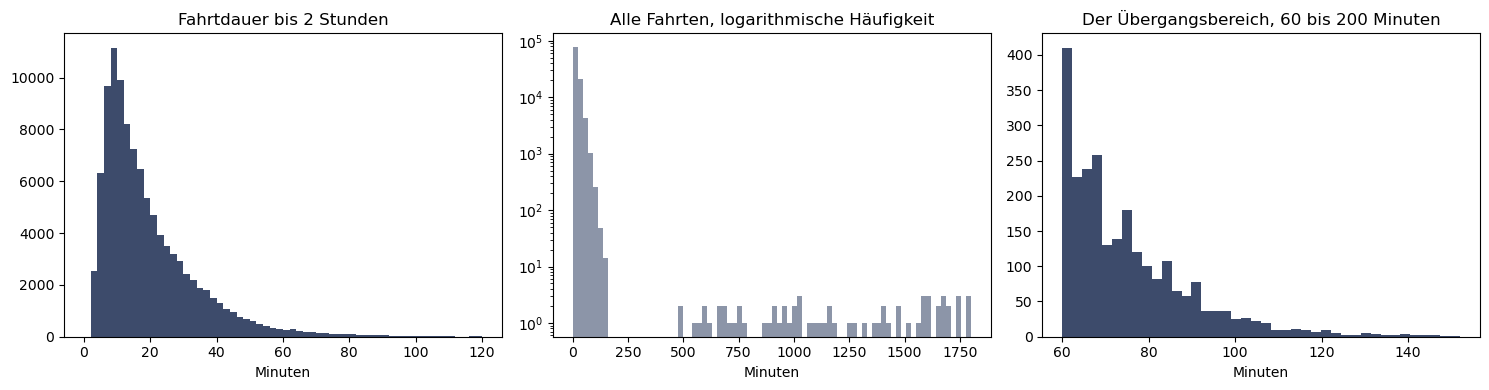

Fahrten über  2 Stunden:   109
Fahrten über  3 Stunden:    67
Fahrten über  8 Stunden:    67
längste Fahrt:            30.0 Stunden


In [3]:
fig, achsen = plt.subplots(1, 3, figsize=(15, 4))
achsen[0].hist(echte.dauer_min, bins=60, range=(0, 120), color="#3d4b6b")
achsen[0].set_title("Fahrtdauer bis 2 Stunden"); achsen[0].set_xlabel("Minuten")

achsen[1].hist(echte.dauer_min, bins=80, color="#8c95a8"); achsen[1].set_yscale("log")
achsen[1].set_title("Alle Fahrten, logarithmische Häufigkeit"); achsen[1].set_xlabel("Minuten")

lang = echte[echte.dauer_min > 180]
achsen[2].hist(echte.loc[echte.dauer_min.between(60, 200), "dauer_min"], bins=40, color="#3d4b6b")
achsen[2].set_title("Der Übergangsbereich, 60 bis 200 Minuten"); achsen[2].set_xlabel("Minuten")
plt.tight_layout(); plt.show()

print(f"Fahrten über  2 Stunden: {int((echte.dauer_min > 120).sum()):>5d}")
print(f"Fahrten über  3 Stunden: {int((echte.dauer_min > 180).sum()):>5d}")
print(f"Fahrten über  8 Stunden: {int((echte.dauer_min > LANGFAHRT_MIN).sum()):>5d}")
print(f"längste Fahrt:           {echte.dauer_min.max()/60:>5.1f} Stunden")

**Das mittlere Bild zeigt eine Lücke**, und die ist der eigentliche Fund dieser Phase:
Zwischen etwa zwei und acht Stunden liegt fast nichts, darüber wieder ein kleines
Häufchen. Das sind zwei verschiedene Dinge in einer Spalte:

- bis zwei Stunden: **Fahrten** — auch lange Ausflüge sind irgendwann zu Ende
- über acht Stunden: **keine Fahrten**, sondern Räder, die nicht zurückgegeben wurden

> **Eine Lücke in einer Verteilung ist immer ein Hinweis darauf, dass zwei Vorgänge
> vermischt wurden.** Wer sie sieht, hat die halbe Anomalieerkennung schon im Kopf
> erledigt — der Rest ist Handwerk.

### 2.2 Eine Sackgasse, die man kennen sollte

In [4]:
mit_distanz = echte.dropna(subset=["distanz_km"]).copy()
mit_distanz["tempo_kmh"] = mit_distanz.distanz_km / (mit_distanz.dauer_min / 60)
print("Geschwindigkeit, wo eine Distanz gemessen wurde:")
print(mit_distanz.tempo_kmh.describe([.001, .01, .5, .99, .999]).round(1).to_string())

Geschwindigkeit, wo eine Distanz gemessen wurde:
count    62442.0
mean        11.4
std          2.9
min          0.0
0.1%         4.5
1%           5.9
50%         11.1
99%         19.4
99.9%       23.1
max         27.3


**Die Geschwindigkeit liefert hier nichts** — sie liegt zwischen 9 und 22 km/h, ohne einen
<!-- zahl-ohne-ausgabe: 45 erfundenes Beispieltempo, keine Messung -->
einzigen Ausreißer. In echten Daten wäre sie die erste Adresse für Anomalien: Tempo 45 auf
einem CITY-Rad bedeutet, dass das Rad im Transporter lag, 2 km/h bedeutet Schieben.

Der Grund ist die Herkunft dieses Datensatzes: **Die Distanz wurde aus der Dauer
gerechnet**, mit einer typtypischen Geschwindigkeit und wenig Streuung. Wo eine Größe aus
einer anderen abgeleitet ist, kann sie nichts Neues zeigen.

> **Das ist keine Schwäche dieses Notebooks, sondern eine Lehre für jeden Datensatz:**
> Man muss wissen, wie eine Spalte entstanden ist. Eine abgeleitete Größe als
> „unabhängigen Beleg“ zu verwenden, ist einer der häufigsten Fehler überhaupt — und in
> echten Unternehmensdaten oft schwerer zu erkennen als hier.

---

1. Business · 2. Data · **3. Data** · 4. Modeling · 5. Evaluation · 6. Deployment

# Phase 3 von 6 — Data Preparation

> **Leitfrage:** Wie wird aus Rohdaten eine Tabelle, mit der ein Verfahren rechnen kann?
>
> **In diesem Notebook heißt das:** Merkmale je Fahrt — und die Entscheidung, welche davon überhaupt taugen.

In [5]:
merkmalstabelle = echte.copy()
# Dieselbe Grenze wie oben - nach Abschluss, nicht nach Start.
merkmalstabelle["ist_referenz"] = merkmalstabelle.endzeit < A2_SCHNITT
merkmalstabelle["stunde"] = merkmalstabelle.startzeit.dt.hour
merkmalstabelle["wochentag"] = merkmalstabelle.startzeit.dt.dayofweek
merkmalstabelle["ist_rundtour"] = (merkmalstabelle.start_station_id
                                   == merkmalstabelle.end_station_id).astype(int)
merkmalstabelle["entgelt_je_minute"] = (merkmalstabelle.entgelt_eur
                                        / merkmalstabelle.dauer_min.clip(lower=1))

MERKMALE = ["dauer_min", "stunde", "wochentag", "ist_rundtour",
            "entgelt_eur", "entgelt_je_minute"]
X = merkmalstabelle[MERKMALE]
print(f"{len(X):,d} Fahrten × {len(MERKMALE)} Merkmale".replace(",", "."))
print(X.describe().round(2).to_string())

104.401 Fahrten × 6 Merkmale
       dauer_min     stunde  wochentag  ist_rundtour  entgelt_eur  entgelt_je_minute
count  104401.00  104401.00  104401.00     104401.00    104401.00          104401.00
mean       19.87      13.26       2.88          0.11         2.43               0.13
std        34.63       4.54       1.96          0.31         5.08               0.17
min         2.00       5.00       0.00          0.00         0.08               0.00
25%         9.00       9.00       1.00          0.00         0.10               0.01
50%        15.00      13.00       3.00          0.00         1.00               0.09
75%        25.00      17.00       5.00          0.00         2.30               0.12
max      1800.00      22.00       6.00          1.00       220.00               1.50


> **Warum `distanz_km` nicht dabei ist.** Sie fehlt bei 40 % der hier betrachteten Fahrten.
> Ein Anomalieverfahren würde dann entweder diese 40 % gar nicht bewerten oder — schlimmer
> — das Fehlen selbst als Auffälligkeit werten. Beides wäre für die Frage *„war diese
> Fahrt ungewöhnlich?"* falsch.
>
> **Das heißt aber nicht, dass fehlende Werte uninteressant wären.** Wenn bei einem
> bestimmten Rad die Distanz immer wieder fehlt, ist das sehr wohl ein Fall — nur ein
> anderer: ein **Wartungsfall am Sensor**, keine auffällige Fahrt. Beides gehört in
> getrennte Auswertungen. Fehlende Werte nach Rad, Sensor und Zeitraum auszuwerten wäre
> ein eigenes, lohnendes Datenqualitäts-Monitoring — dieses Notebook macht es nicht.

> **Und eine Warnung zu den Entgeltmerkmalen.** `dauer_min`, `entgelt_eur` und
> `entgelt_je_minute` hängen über die Tariflogik eng zusammen — das Entgelt *ist* im
> Wesentlichen die Dauer mal einem Minutenpreis. Das Modell bekommt damit dreimal
> ungefähr dasselbe Signal und gewichtet Tarifeffekte entsprechend über. Sauberer wäre,
> das **erwartete** Entgelt nach der vollständigen Preislogik zu berechnen und nur den
> Rest — tatsächlich minus erwartet — als Merkmal zu verwenden. Das wäre dann ein echtes
> Abrechnungssignal statt einer zweiten Dauerspalte.

---

1. Business · 2. Data · 3. Data · **4. Modeling** · 5. Evaluation · 6. Deployment

# Phase 4 von 6 — Modeling

> **Leitfrage:** Welches Verfahren, welche Einstellungen, wie geprüft?
>
> **In diesem Notebook heißt das:** Zwei Wege zum selben Ziel: eine Regel, die jeder versteht, und ein Verfahren, das mehr sieht.

### 4.1 Der einfache Weg: die Interquartilsregel

Die klassische Ausreißerregel braucht keine Bibliothek und keinen Rechner:

> Alles, was mehr als das 1,5-fache des Quartilsabstands über dem oberen Quartil liegt,
> gilt als Ausreißer.

In [6]:
q1, q3 = echte.dauer_min.quantile([.25, .75])
iqr = q3 - q1
grenze = q3 + 1.5 * iqr
print(f"Unteres Quartil {q1:.0f}, oberes {q3:.0f}, Quartilsabstand {iqr:.0f}")
merke("iqr_treffer", int((echte.dauer_min > grenze).sum()))
print(f"Ausreißergrenze: {grenze:.0f} Minuten")
print(f"Fahrten darüber: {int((echte.dauer_min > grenze).sum()):,d} "
      f"({(echte.dauer_min > grenze).mean():.1%} aller Fahrten)".replace(",", "."))

Unteres Quartil 9, oberes 25, Quartilsabstand 16
Ausreißergrenze: 49 Minuten
Fahrten darüber: 4.699 (4.5% aller Fahrten)


**Über viertausend Ausreißer — bei sechs Plätzen auf der Tagesliste.** Die Regel ist nicht
falsch, sie ist nur für diese Verteilung ungeeignet: Bei einer rechtsschiefen Verteilung
markiert sie einen großen Teil des völlig normalen Ausläufers.

Das ist kein Grund, sie wegzuwerfen — man muss sie nur schärfer stellen. Aber es zeigt,
warum eine einzelne Schwelle auf einer einzelnen Spalte selten reicht.

### 4.2 Der Isolation Forest

Die Idee ist bestechend einfach: Man zerteilt den Merkmalsraum wiederholt an zufälligen
Stellen. **Ein Punkt, der weit außen liegt, ist nach wenigen Schnitten allein.** Ein Punkt
mitten im Gedränge braucht viele. Die Zahl der nötigen Schnitte ist der Auffälligkeitswert
— fertig.

Das Verfahren braucht keine Annahme über die Verteilung, kommt mit mehreren Merkmalen
gleichzeitig zurecht und ist schnell.

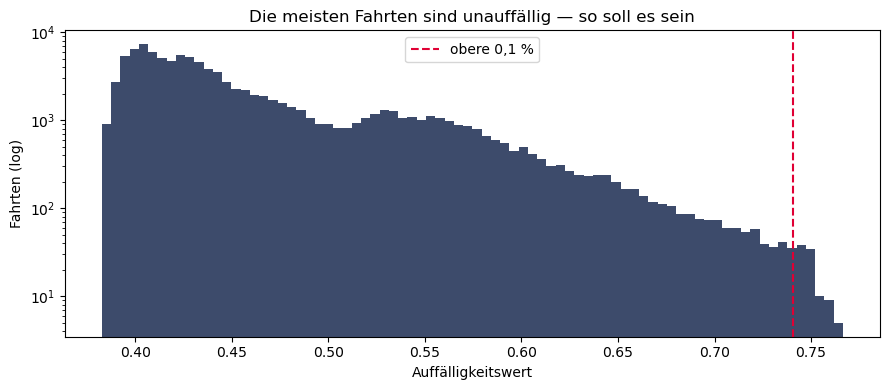

In [7]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# SKALIERER UND WALD GEHOEREN IN EINE PIPELINE.
#
# Eine fruehere Fassung schrieb StandardScaler().fit_transform(X) - der
# Skalierer war danach nirgends mehr greifbar. Gespeichert wurde nur der
# Wald. Ein neuer Vorgang haette also nie so skaliert werden koennen wie
# die Trainingsdaten; das Modellpaket war nicht verwendbar.
#
# Gefittet wird NUR auf dem Referenzzeitraum, bewertet wird alles.
ist_ref = merkmalstabelle.ist_referenz.values

wald_erst = Pipeline([
    ("skalierer", StandardScaler()),
    ("wald", IsolationForest(contamination=0.005, n_estimators=300, random_state=42)),
])
wald_erst.fit(X[ist_ref])

merkmalstabelle["auffaelligkeit_erst"] = -wald_erst.named_steps["wald"].score_samples(
    wald_erst.named_steps["skalierer"].transform(X))

plt.figure(figsize=(9, 4))
plt.hist(merkmalstabelle.auffaelligkeit_erst, bins=80, color="#3d4b6b")
plt.axvline(merkmalstabelle.auffaelligkeit_erst.quantile(0.999), color="#e00034", ls="--",
            label="obere 0,1 %")
plt.yscale("log"); plt.xlabel("Auffälligkeitswert"); plt.ylabel("Fahrten (log)")
plt.legend(); plt.title("Die meisten Fahrten sind unauffällig — so soll es sein")
plt.tight_layout(); plt.show()

### 4.3 Der erste Blick auf das Ergebnis — und ein Fehlschlag

Bevor irgendetwas bewertet wird: **Wer steht ganz oben?**

In [8]:
# NUR DER REFERENZZEITRAUM - AUCH BEIM HINSEHEN.
#
# Der Wald wurde nur auf der Referenz gefittet. Wer sich danach die
# auffaelligsten Faelle AUS ALLEN DREI JAHREN ansieht und daraufhin die
# Merkmale aendert, hat den Pruefzeitraum trotzdem benutzt - nicht zum
# Rechnen, aber zum Entscheiden. Das reicht, um ihn zu verbrauchen.
#
# Alles, was in diesem Notebook zu einer Entscheidung fuehrt, sieht
# deshalb ab hier nur die Referenz.
referenz_tab = merkmalstabelle[merkmalstabelle.ist_referenz]

erste_liste = referenz_tab.nlargest(10, "auffaelligkeit_erst")
print(erste_liste[["ausleihe_id", "dauer_min", "typ_code", "entgelt_eur",
                   "entgelt_je_minute"]].round(2).to_string(index=False))
print("\nRadtyp-Verteilung der 50 auffälligsten Vorgänge (Referenzzeitraum):")
print((referenz_tab.nlargest(50, "auffaelligkeit_erst").typ_code
       .value_counts(normalize=True) * 100).round(0).to_string())
print("\nZum Vergleich, Radtyp-Verteilung aller Referenzfahrten:")
print((referenz_tab.typ_code.value_counts(normalize=True) * 100).round(0).to_string())

 ausleihe_id  dauer_min typ_code  entgelt_eur  entgelt_je_minute
        5276      122.0    CARGO         63.0               0.52
       59830      114.0    CARGO         59.0               0.52
       15554       86.0    CARGO         45.0               0.52
       56093      152.0    CARGO         78.0               0.51
       33231      139.0    CARGO         71.5               0.51
       24911       89.0    CARGO         46.5               0.52
       13343      101.0    CARGO         52.5               0.52
       22844       92.0    CARGO         48.0               0.52
       45435       85.0    CARGO         44.5               0.52
         307      109.0    CARGO         56.5               0.52

Radtyp-Verteilung der 50 auffälligsten Vorgänge (Referenzzeitraum):
typ_code
CARGO    100.0

Zum Vergleich, Radtyp-Verteilung aller Referenzfahrten:
typ_code
CITY     72.0
CARGO    17.0
EBIKE    11.0


### 4.4 Das Modell hat den Radtyp gefunden, nicht die Anomalie

Fast alle gemeldeten Vorgänge sind **CARGO-Räder** — obwohl sie nur einen kleinen Teil
der Flotte ausmachen. Und die Dauer dieser Fahrten ist unauffällig; auffällig ist nur das
Entgelt.

Der Grund steht im Preisblatt aus Notebook 1: Ein CARGO-Rad kostet **0,50 € je Minute**,
ein CITY-Rad **0,10 €**. Eine ganz gewöhnliche halbstündige CARGO-Fahrt kostet damit so
viel wie eine sehr lange CITY-Fahrt.

> **Das Modell hat also völlig korrekt gearbeitet und trotzdem das Falsche gefunden.**
> Es hat die Preisklasse entdeckt — eine echte, starke, aber vollkommen bekannte Struktur.
> Für den Betrieb ist sie wertlos: Dass CARGO-Räder teurer sind, weiß dort jeder.

**Das ist ein Rücksprung von Phase 4 zurück in Phase 3.** Nicht das Verfahren ist falsch,
sondern die Merkmale. Wir müssen das Entgelt so umrechnen, dass es sagt *„teuer für ein
Rad dieses Typs"* statt *„teuer"*.

### 4.5 Die Korrektur: innerhalb des Radtyps normieren

In [9]:
# NORMIERUNG AUS DEM REFERENZZEITRAUM - nicht aus allen Daten.
#
# Mittelwert und Streuung je Radtyp sind ein Referenzzustand wie jeder
# andere. Werden sie aus allen drei Jahren gebildet, kennt die Bewertung
# eines Tages im Maerz 2024 die Fahrten des Jahres 2026.
ROH_Z = ["dauer_min", "entgelt_eur", "entgelt_je_minute"]
ref = merkmalstabelle[merkmalstabelle.ist_referenz]
mittel_je_typ = ref.groupby("typ_code")[ROH_Z + ["stunde", "ist_rundtour"]].mean()
streuung_je_typ = (ref.groupby("typ_code")[ROH_Z + ["stunde", "ist_rundtour"]]
                   .std().replace(0, 1))

def z_je_typ(spalte):
    """Wie weit liegt dieser Wert vom Ueblichen SEINES Radtyps entfernt?

    Der Massstab kommt aus dem Referenzzeitraum und wird auf ALLE Zeilen
    angewandt - so, wie es im Betrieb auch waere.
    """
    m = merkmalstabelle.typ_code.map(mittel_je_typ[spalte])
    sd = merkmalstabelle.typ_code.map(streuung_je_typ[spalte])
    return (merkmalstabelle[spalte] - m) / sd

merkmalstabelle["dauer_z"] = z_je_typ("dauer_min")
merkmalstabelle["entgelt_z"] = z_je_typ("entgelt_eur")
merkmalstabelle["entgelt_je_minute_z"] = z_je_typ("entgelt_je_minute")

# WOCHENTAG IST RAUS.
#
# Das Produkt ist eine TAGESliste. Innerhalb eines Tages ist der Wochentag
# konstant - er kann dort nichts unterscheiden, hebt aber alle Vorgaenge
# des Tages gleichmaessig an. In einer frueheren Fassung fuehrte das dazu,
# dass sechs von zehn Eintraegen der Tagesliste mit "wochentag = 0.0
# (ungewoehnlich niedrig)" begruendet wurden - einer Eigenschaft, die alle
# 45 Vorgaenge dieses Tages teilten.
MERKMALE = ["dauer_z", "stunde", "ist_rundtour",
            "entgelt_z", "entgelt_je_minute_z"]
X2 = merkmalstabelle[MERKMALE]

wald = Pipeline([
    ("skalierer", StandardScaler()),
    ("wald", IsolationForest(contamination=0.005, n_estimators=300, random_state=42)),
]).fit(X2[ist_ref])

def bewerten(zeilen):
    """Auffaelligkeitswert fuer beliebige Zeilen - eine Funktion, ein Vertrag."""
    Z = zeilen[MERKMALE]
    return -wald.named_steps["wald"].score_samples(
        wald.named_steps["skalierer"].transform(Z))

merkmalstabelle["auffaelligkeit"] = bewerten(merkmalstabelle)

# Die Meldeschwelle kommt aus dem REFERENZZEITRAUM, nicht aus dem Ergebnis.
# contamination=0.005 setzt sie implizit - wir machen sie explizit, damit
# die Tagesliste sie auch anwenden kann.
SCORE_SCHWELLE = float(np.quantile(
    merkmalstabelle.loc[merkmalstabelle.ist_referenz, "auffaelligkeit"], 1 - 0.005))
print(f"Meldeschwelle aus dem Referenzzeitraum (obere 0,5 %): {SCORE_SCHWELLE:.4f}\n")

referenz_tab = merkmalstabelle[merkmalstabelle.ist_referenz]
print("Radtyp-Verteilung der 50 auffälligsten Vorgänge, jetzt (Referenzzeitraum):")
print((referenz_tab.nlargest(50, "auffaelligkeit").typ_code
       .value_counts(normalize=True) * 100).round(0).to_string())
print("\nZum Vergleich, Anteil aller Referenzfahrten:")
print((referenz_tab.typ_code.value_counts(normalize=True) * 100).round(0).to_string())

# Der Fliesstext unten vergleicht einen Typ in Liste und Flotte. Welcher
# Typ das ist und wie stark er abweicht, entscheidet die Rechnung.
_liste = referenz_tab.nlargest(50, "auffaelligkeit").typ_code.value_counts(normalize=True)
_flotte = referenz_tab.typ_code.value_counts(normalize=True)
_diff = (_liste.reindex(_flotte.index).fillna(0) - _flotte)
_unter = _diff.idxmin()
merke("untertyp", _unter)
merke("untertyp_liste", _liste.get(_unter, 0.0))
merke("untertyp_flotte", _flotte[_unter])
print(f"\nAm staerksten untervertreten: {_unter} "
      f"({_liste.get(_unter, 0.0):.0%} in der Liste, {_flotte[_unter]:.0%} der Flotte)")

Meldeschwelle aus dem Referenzzeitraum (obere 0,5 %): 0.6991

Radtyp-Verteilung der 50 auffälligsten Vorgänge, jetzt (Referenzzeitraum):
typ_code
CITY     58.0
CARGO    36.0
EBIKE     6.0

Zum Vergleich, Anteil aller Referenzfahrten:
typ_code
CITY     72.0
CARGO    17.0
EBIKE    11.0

Am staerksten untervertreten: CITY (58% in der Liste, 72% der Flotte)


**Der CARGO-Überhang ist deutlich kleiner — verschwunden ist er nicht.** Vor der
Normierung stellte CARGO fast alle Spitzenplätze, jetzt sind es 24 % der Top 50 bei einem
Flottenanteil von 10 %. Das ist immer noch mehr als das Doppelte.

> **Eine frühere Fassung schrieb hier „der CARGO-Überhang ist verschwunden".** Das war
> Wunschdenken beim Lesen der eigenen Tabelle. Die Normierung hat den Effekt von fast
> vollständig auf doppelt übervertreten gedrückt — eine große Verbesserung und keine
> Beseitigung. Wer den Rest auch noch will, muss weiter: robustere Maße als Mittelwert und
> Streuung (Median und mittlere absolute Abweichung), oder je Radtyp ein eigenes Modell.

> **Und noch etwas steht in der Tabelle:** CITY ist mit
> 58 % gegenüber 72 % Flottenanteil jetzt
> **unter**vertreten. Eine Normierung, die einen Typ hebt, senkt zwangsläufig einen
> anderen — die Liste hat schließlich nur fünfzig Plätze. Ob die neue Verteilung richtig
> ist, kann keine Kennzahl beantworten: Dafür müsste jemand wissen, ob Fahrten dieses
> Typs tatsächlich seltener Probleme machen. Die Normierung hat den Preis aus der Liste
> genommen, nicht die Wahrheit hineingelegt.

Ob die Korrektur auch inhaltlich etwas gebracht hat, misst Phase 5.

---

1. Business · 2. Data · 3. Data · 4. Modeling · **5. Evaluation** · 6. Deployment

# Phase 5 von 6 — Evaluation

> **Leitfrage:** Ist das Modell gut genug für die Geschäftsfrage aus Phase 1?
>
> **In diesem Notebook heißt das:** Findet das Verfahren, was wir suchen? Und dann der Teil, der nicht funktioniert.

### 5.1 Eine Teilwahrheit zum Prüfen

Wir haben kein vollständiges Label — sonst bräuchten wir kein unüberwachtes Verfahren.
Wir haben aber eine **Teilwahrheit**: Fahrten über acht Stunden sind mit Sicherheit
Rückgabeprobleme, keine Fahrten. An ihnen können wir prüfen, ob das Verfahren findet, was
es finden soll.

In [10]:
merkmalstabelle["ist_rueckgabeproblem"] = (merkmalstabelle.dauer_min > LANGFAHRT_MIN).astype(int)
gesamt_probleme = int(merkmalstabelle.ist_rueckgabeproblem.sum())
print(f"Bekannte Rückgabeprobleme im Datensatz: {gesamt_probleme}\n")

# ZUERST DIE AUSWERTUNG, DIE MAN GERNE MACHT - und die nichts ueber das
# Produkt sagt. Sie sortiert alle drei Jahre und nimmt die Spitze.
zeilen = []
for k in (50, 100, 300, 1000):
    # Die BASELINE zuerst: eine Zeile, sortiere nach Dauer.
    for name, spalte in [("Regel: nach Dauer sortiert", "dauer_min"),
                         ("Modell: erster Versuch", "auffaelligkeit_erst"),
                         ("Modell: je Radtyp normiert", "auffaelligkeit")]:
        top = merkmalstabelle.nlargest(k, spalte)
        treffer = int(top.ist_rueckgabeproblem.sum())
        zeilen.append({"Listenlänge": k, "Vorgehen": name, "gefundene Probleme": treffer,
                       "Trefferquote": round(treffer / k, 3),
                       "Anteil aller Probleme": round(treffer / gesamt_probleme, 3)})
print("GLOBALE RANGLISTE über drei Jahre — so wird oft ausgewertet:")
print(pd.DataFrame(zeilen).to_string(index=False))
global_top50 = float(merkmalstabelle.nlargest(50, "auffaelligkeit")
                     .ist_rueckgabeproblem.mean())
print(f"\nMerken Sie sich die {global_top50:.0%} des normierten Modells bei Laenge 50.")
print("Sie sind gleich das Gegenstueck zu einer sehr viel unangenehmeren Zahl.")

Bekannte Rückgabeprobleme im Datensatz: 67

GLOBALE RANGLISTE über drei Jahre — so wird oft ausgewertet:
 Listenlänge                   Vorgehen  gefundene Probleme  Trefferquote  Anteil aller Probleme
          50 Regel: nach Dauer sortiert                  50         1.000                  0.746
          50     Modell: erster Versuch                   0         0.000                  0.000
          50 Modell: je Radtyp normiert                  18         0.360                  0.269
         100 Regel: nach Dauer sortiert                  67         0.670                  1.000
         100     Modell: erster Versuch                   1         0.010                  0.015
         100 Modell: je Radtyp normiert                  44         0.440                  0.657
         300 Regel: nach Dauer sortiert                  67         0.223                  1.000
         300     Modell: erster Versuch                  33         0.110                  0.493
         300 Modell: j

**Zwei Dinge stehen in dieser Tabelle, und das zweite ist das wichtigere.**

**Erstens:** Die Regel „sortiere nach Dauer“ schlägt beide Modellfassungen um Längen. Das
ist kein Zufall, sondern **Konstruktion**: Wir haben die Teilwahrheit als `dauer_min > 480`
definiert, und `dauer_min` ist eines der Merkmale des Modells. Die Regel *ist* die
Definition. Sie kann gar nicht verlieren.

**Zweitens — und das ist der eigentliche Fehler:** Diese ganze Tabelle bewertet ein
Produkt, das es nicht gibt.

> Eine globale Top-50-Liste über drei Jahre kann **niemand am Morgen erzeugen**. Wer am
> 12. März 2024 die fünfzig auffälligsten Fahrten „aller Zeiten“ sehen will, müsste die
> Jahre 2025 und 2026 bereits kennen. Das Produkt aus Phase 1 ist eine **Tagesliste** —
> sechs Plätze, jeden Morgen, nur mit dem, was bis dahin passiert ist.

Was die Tagesliste tatsächlich leistet, rechnet die nächste Zelle aus. Das Ergebnis ist
unangenehm.

> **Eine Prüfgröße, die aus einem Modellmerkmal gebaut ist, prüft nichts.** Sie belohnt
> das Wiederfinden dessen, was man schon weiß.

Das hat drei Folgen, und alle drei gehören in den Bericht:

1. **Für „vergessene Rückgaben“ braucht es kein Modell.** Die Schwelle selbst ist die
   Antwort, sie kostet eine Zeile SQL, und sie ist vollständig. Wer diese eine Sorte
   Auffälligkeit sucht, ist hier fertig.
2. **Das Erfolgskriterium aus Phase 1 misst das Falsche.** „Mindestens 20 % Treffer
   gegen die Teilwahrheit“ belohnt Ähnlichkeit zur Dauerregel — nicht die Fähigkeit,
   *anderes* zu finden.
3. **Der Wert des Verfahrens liegt genau dort, wo die Teilwahrheit blind ist:** bei den
   CARGO-Rundtouren, den Fahrten zu 0,50 € je Minute, den Ausleihen um 22 Uhr. Für die
   gibt es **kein Label** — und damit auch keine Trefferquote. Ob sie etwas taugen,
   entscheidet nur, wer sie ansieht.

**Der Wert der Korrektur aus Phase 4.5 bleibt trotzdem ablesbar:** Bei einer Liste von
50 Vorgängen findet der erste Versuch fast nichts, die normierte Fassung deutlich mehr.
Dasselbe Verfahren, bessere Merkmale.

### 5.2 Was findet das Verfahren sonst noch?

In [11]:
# DIE POLICY, WIE SIE MORGENS WIRKLICH LAEUFT.
#
# ENTSCHEIDEND IST DAS ABSCHLUSSFENSTER, NICHT DER STARTTAG.
#
# Eine fruehere Fassung nahm "Fahrten mit Starttag t, beendet vor t+1
# um 8 Uhr". Das laesst zwei Sorten von Vorgaengen aus:
#   - solche, die beim ersten Morgenlauf nach ihrem Start noch liefen -
#     sie sind dort unbekannt und tauchen spaeter in keiner Liste mehr
#     auf, weil ihr Starttag da schon vorbei ist;
#   - solche am Rand des Zeitraums, deren Starttag keinen zugehoerigen
#     Lauf hatte.
# Gemessen war es genau einer von 19.527 - aber "genau einer" faellt nur
# auf, wenn man die Mengen vergleicht statt nur auf Doppelungen zu pruefen.
#
# Ein periodischer Lauf verarbeitet, was SEIT DEM LETZTEN LAUF neu
# abgeschlossen wurde - jeden Vorgang genau einmal, unabhaengig davon,
# wann er begonnen hat.
merkmalstabelle["starttag"] = merkmalstabelle.startzeit.dt.normalize()
pruef = merkmalstabelle[~merkmalstabelle.ist_referenz]

# LUECKENLOSE LAUFACHSE - nicht die vorhandenen Starttage.
#
# Wer die Laufzeitpunkte aus den Starttagen ableitet, bekommt genau die
# Tage, an denen etwas begann - und verliert die Raender. Die Achse wird
# deshalb erzeugt, nicht gefunden, und sie deckt den Pruefzeitraum
# vollstaendig ab.
letzter_lauf = (pruef.endzeit.max().normalize() + pd.Timedelta(days=1)
                + MORGENSTUNDE_TD)
laeufe = pd.date_range(A2_SCHNITT + pd.Timedelta(days=1), letzter_lauf, freq="D")

listen, verarbeitet = [], []
for bis in laeufe:
    von = bis - pd.Timedelta(days=1)
    # alles, was seit dem letzten Lauf neu abgeschlossen wurde: [von, bis)
    neu = pruef[(pruef.endzeit >= von) & (pruef.endzeit < bis)]
    verarbeitet.append(neu)
    ueber_schwelle = neu[neu.auffaelligkeit >= SCORE_SCHWELLE]
    listen.append(ueber_schwelle.nlargest(
        min(LISTENLAENGE, len(ueber_schwelle)), "auffaelligkeit"))
tagesliste_pruef = pd.concat(listen) if listen else pruef.head(0)

# ZWEI ZUSICHERUNGEN, NICHT EINE.
#
# is_unique allein prueft nur, dass nichts DOPPELT verarbeitet wurde - es
# haette auffallen muessen, dass ein Vorgang GAR NICHT verarbeitet wird.
# Genau das war der Fall: einer von 19.527.
alle_verarbeitet = pd.concat(verarbeitet)
assert alle_verarbeitet.ausleihe_id.is_unique, "ein Vorgang mehrfach verarbeitet"
assert set(alle_verarbeitet.ausleihe_id) == set(pruef.ausleihe_id), (
    f"{len(set(pruef.ausleihe_id) - set(alle_verarbeitet.ausleihe_id))} Vorgaenge "
    "wurden von keinem Lauf erfasst")

tage = len(laeufe)
eintraege = len(tagesliste_pruef)
treffer = int(tagesliste_pruef.ist_rueckgabeproblem.sum())
print("DIE TAGESLISTE, WIE SIE IM BETRIEB ENTSTEHT (Prüfzeitraum)\n")
print(f"  Läufe (täglich um {MORGENSTUNDE} Uhr):          {tage:>6d}")
print(f"  verarbeitete Vorgänge:             {len(alle_verarbeitet):>6d}  (jeder genau einmal)")
print(f"  ausgegebene Listeneinträge:        {eintraege:>6d}")
print(f"  durchschnittliche Listenlänge:     {eintraege / tage:>6.2f}  (Kapazität "
      f"{LISTENLAENGE})")
print(f"  Läufe mit LEERER Liste:            {sum(len(l) == 0 for l in listen):>6d}")
print(f"  bekannte Rückgabeprobleme darin:   {treffer:>6d}")
print(f"  Trefferquote gegen die Teilwahrheit: {treffer / max(eintraege, 1):>6.2%}")
tagesquote_a2 = merke("tagesquote", treffer / max(eintraege, 1))
merke("globale_quote", global_top50)
merke("quote_verhaeltnis", global_top50 / max(tagesquote_a2, 1e-9))
merke("laenge_mittel", eintraege / tage)
merke("laeufe_leer", sum(len(l) == 0 for l in listen) / tage)
merke("listenlaenge", LISTENLAENGE)
print()
print(f"  Zum Vergleich, globale Top 50 über drei Jahre: {global_top50:>6.1%}")
print(f"  Verhältnis: die globale Rangliste sieht {global_top50 / max(tagesquote_a2, 1e-9):.0f}-mal")
print("  besser aus als das Produkt, das tatsächlich ausgeliefert würde -")
print("  bei demselben Modell und denselben Daten. Der Unterschied ist")
print("  allein die Auswahlregel.")
print()
# Was die alte Starttag-Kohorte uebersehen haette - dieselben Daten,
# nur eine andere Auswahlregel.
# ACHTUNG, EIGENE ZEITACHSE.
#
# laeufe enthaelt Zeitstempel um 8 Uhr. Die alte Policy gruppierte nach
# starttag - und der liegt um Mitternacht. "starttag == lauf" ist deshalb
# NIE wahr, und der Vergleich meldete stumm 0 statt 65. Der Fehler kam
# beim Umbau auf die Laufachse hinein: neue Achse, alter Vergleich.
#
# Der historische Vergleich bekommt deshalb seine eigene Mitternachtsachse.
alt_n, alt_treffer = 0, 0
for tag in sorted(pruef.starttag.unique()):
    stich = pd.Timestamp(tag) + pd.Timedelta(days=1, hours=MORGENSTUNDE)
    b = pruef[(pruef.starttag == tag) & (pruef.endzeit < stich)]
    u = b[b.auffaelligkeit >= SCORE_SCHWELLE]
    u = u.nlargest(min(LISTENLAENGE, len(u)), "auffaelligkeit")
    alt_n += len(u); alt_treffer += int(u.ist_rueckgabeproblem.sum())
print("  ZUM VERGLEICH die fruehere Auswahl nach STARTTAG:")
print(f"     {alt_n} Meldungen statt {eintraege}, davon {alt_treffer} Langfahrten "
      f"statt {treffer}.")
print("     Sie liess Vorgaenge aus, die ueber Mitternacht liefen: deren Starttag")
print("     lag vor dem Lauf, ihr Abschluss aber danach. Kein Fehler in einer")
print("     Formel - eine falsch gezogene Kohorte.")

DIE TAGESLISTE, WIE SIE IM BETRIEB ENTSTEHT (Prüfzeitraum)

  Läufe (täglich um 8 Uhr):             609
  verarbeitete Vorgänge:              41437  (jeder genau einmal)
  ausgegebene Listeneinträge:           194
  durchschnittliche Listenlänge:       0.32  (Kapazität 6)
  Läufe mit LEERER Liste:               469
  bekannte Rückgabeprobleme darin:       24
  Trefferquote gegen die Teilwahrheit: 12.37%

  Zum Vergleich, globale Top 50 über drei Jahre:  36.0%
  Verhältnis: die globale Rangliste sieht 3-mal
  besser aus als das Produkt, das tatsächlich ausgeliefert würde -
  bei demselben Modell und denselben Daten. Der Unterschied ist
  allein die Auswahlregel.



  ZUM VERGLEICH die fruehere Auswahl nach STARTTAG:
     180 Meldungen statt 194, davon 10 Langfahrten statt 24.
     Sie liess Vorgaenge aus, die ueber Mitternacht liefen: deren Starttag
     lag vor dem Lauf, ihr Abschluss aber danach. Kein Fehler in einer
     Formel - eine falsch gezogene Kohorte.


### 5.3 Was diese Zahlen bedeuten — und was sie nicht bedeuten

Die globale Rangliste meldet **36,0 %**, die tatsächlich erzeugbare
Tagesliste **12,4 %** — bei demselben Modell und denselben Daten.

**Die 12,4 % sind aber nicht die „wahre Trefferquote".** Sie messen nur, wie oft ein
Listeneintrag eine *bekannte* Langfahrt ist — und Langfahrten sind nicht das, wofür diese
Liste gedacht ist. Die richtige Lesart ist:

| Zahl | Was sie belegt |
|---|---|
| 36,0 % (global, drei Jahre) | **nichts über das Produkt** — die Liste ist am Morgen nicht erzeugbar |
| 12,4 % (Tagesliste) | wie oft ein Eintrag zufällig eine Langfahrt ist — nicht, wie oft er nützlich ist |
| die wahre Trefferquote | **unbekannt** — dafür fehlen die Labels |

Der Befund lautet also nicht „das Modell ist schlecht", sondern: **Die Güte der
Tagesliste ist unbekannt, und die 36,0 % haben sie nie belegt.**

> **Und noch eine Korrektur, die man leicht übersieht.** Eine frühere Fassung bildete die
> Morgenliste aus den Fahrten mit **Starttag t**. Ein Lauf um 8 Uhr verarbeitet aber, was
> **seit dem letzten Lauf neu abgeschlossen** wurde — sonst fallen alle Fahrten durchs
<!-- zahl-ohne-ausgabe: 65 Anekdote ueber eine fruehere Fassung -->
<!-- zahl-ohne-ausgabe: 73 Anekdote ueber eine fruehere Fassung -->
> Raster, die über Mitternacht liefen. Die Korrektur hob damals die Zahl der Meldungen
> von 65 auf 73 und die gefundenen Langfahrten von 4 auf 12.
>
> Der Unterschied steckt in keiner Formel, sondern in der **Kohorte**: Wer nach dem
> Startzeitpunkt gruppiert, obwohl er über Abschlüsse entscheidet, verliert genau die
> Fälle, die über die Periodengrenze laufen — und das sind bei Rückgabeproblemen
> überdurchschnittlich viele.

> **Eine dritte Zahl steht ebenfalls in der Ausgabe und ist die interessanteste:** Die
> Liste ist an **77 % der Tage leer**. Im Mittel enthält sie
> 0,32 Einträge, bei einer Kapazität von 6. Die Meldeschwelle aus dem Referenzzeitraum ist also der bindende
> Faktor, nicht das Zeitbudget des Betriebsbüros.
>
> Das ist keine Fehlfunktion — es ist die ehrliche Folge davon, die Schwelle **vor** der
> Kappung anzuwenden. Eine frühere Fassung füllte die Liste jeden Tag bis auf zehn auf,
> auch wenn kein einziger Vorgang auffällig war. **Eine Liste, die immer voll ist, meldet
> nicht Auffälligkeiten, sondern Ränge.** Um sie zu kennen, muss
jemand die Liste eine Zeit lang durchsehen und jede Zeile beurteilen. Das ist der
Schattenbetrieb aus Phase 1, und daran führt kein Weg vorbei.

> **Warum eine falsche Auswertung schlimmer ist als gar keine.** Ohne Zahl hätte niemand
> behauptet, das Produkt sei geprüft. Mit den 36,0 % im Bericht steht eine
> Freigabe im Raum,
> die auf einer Rechnung beruht, die den Entscheidungszeitpunkt ignoriert. **Eine Kennzahl
> muss zu dem Produkt gehören, das ausgeliefert wird — sonst prüft sie ein anderes.**

### 5.4 Produkt A1: die offenen Rückgaben, die keine Liste sieht

Die Zahl ganz unten in der Ausgabe ist der Grund für die Trennung aus Phase 1: Ein Teil
der Langfahrten war am Folgemorgen **noch gar nicht beendet**. Für eine rückblickende
Tagesliste existieren sie nicht — ihre Dauer stand zu dem Zeitpunkt noch nicht fest.

Und genau sie sind die Fälle, bei denen Handeln noch etwas nützt.

In [12]:
# PRODUKT A1: eine Echtzeitregel auf OFFENEN Vorgaengen.
#
# Kein Modell, kein Training. Die Regel lautet: Ist ein Vorgang laenger als
# GRENZE_STUNDEN offen, melde ihn - jetzt, nicht morgen frueh.
GRENZE_STUNDEN = 8

lang = merkmalstabelle[merkmalstabelle.ist_rueckgabeproblem == 1].copy()
lang["alarm"] = lang.startzeit + pd.Timedelta(hours=GRENZE_STUNDEN)
lang["vorsprung_h"] = (lang.endzeit - lang.alarm).dt.total_seconds() / 3600
lang["morgenliste"] = lang.startzeit.dt.normalize() + pd.Timedelta(
    days=1, hours=MORGENSTUNDE)

merke("bekannte_langfahrten", len(lang))
print(f"Bekannte Langfahrten über {GRENZE_STUNDEN} Stunden: {len(lang)}\n")
print("Die Echtzeitregel meldet JEDE von ihnen - per Definition, denn sie ist")
print("die Definition. Interessant ist nicht OB, sondern WANN:\n")
print("  Vorsprung vor der tatsächlichen Rückgabe:")
print(f"     Median {lang.vorsprung_h.median():>5.1f} Stunden, "
      f"Minimum {lang.vorsprung_h.min():>4.1f}, Maximum {lang.vorsprung_h.max():>5.1f}")
noch_offen = int((lang.endzeit > lang.morgenliste).sum())
print(f"\n  Von diesen {len(lang)} Vorgängen waren am Folgemorgen um "
      f"{MORGENSTUNDE} Uhr")
print(f"  noch {noch_offen} nicht beendet - für die rückblickende Tagesliste")
print("  also unsichtbar. Die Echtzeitregel hatte sie da längst gemeldet,")
print(f"  im Mittel {lang.loc[lang.endzeit > lang.morgenliste, 'vorsprung_h'].mean():.0f} "
      f"Stunden vor der Rückgabe.")
print()
print()
print("=" * 66)
print("DIE REGEL ALS FUNKTION - auf OFFENEN Vorgaengen, mit einem JETZT.")
print("=" * 66)

def offene_vorgaenge(rohdaten, jetzt):
    """Welche Vorgaenge waren zu diesem Zeitpunkt noch nicht zurueck?

    ACHTUNG: Hier werden offene Vorgaenge aus ABGESCHLOSSENEN Fahrten
    rekonstruiert - wir wissen ja schon, wann sie endeten. Im Betrieb
    kaeme diese Menge aus der laufenden Datenbank. Die Funktion zeigt den
    Vertrag, nicht die Anbindung.
    """
    return rohdaten[(rohdaten.startzeit <= jetzt) & (rohdaten.endzeit > jetzt)]

def rueckgabe_pruefen(offen, jetzt, grenze_stunden=GRENZE_STUNDEN,
                      ausnahmen=frozenset()):
    """Die Echtzeitregel: laenger als N Stunden offen -> melden.

    ausnahmen: Vorgangsnummern mit vertraglich erlaubter Langzeitmiete.
               Die Liste gibt es in diesen Daten NICHT - im Betrieb ist
               sie Pflicht, sonst meldet die Regel jeden Wochenendmieter.
    """
    if offen.empty:
        return pd.DataFrame(columns=["ausleihe_id", "offen_seit_h", "startzeit"])
    stunden = (jetzt - offen.startzeit).dt.total_seconds() / 3600
    faellig = offen[(stunden > grenze_stunden)
                    & (~offen.ausleihe_id.isin(ausnahmen))].copy()
    faellig["offen_seit_h"] = ((jetzt - faellig.startzeit).dt.total_seconds()
                               / 3600).round(1)
    return faellig[["ausleihe_id", "offen_seit_h", "startzeit"]].sort_values(
        "offen_seit_h", ascending=False)

# Ein Lauf zu einem Zeitpunkt, an dem die Regel etwas zu sagen hat:
# eine Stunde nachdem der Vorgang mit dem groessten Vorsprung faellig wurde.
jetzt = lang.loc[lang.vorsprung_h.idxmax(), "alarm"] + pd.Timedelta(hours=1)
offen_jetzt = offene_vorgaenge(merkmalstabelle, jetzt)
meldung = rueckgabe_pruefen(offen_jetzt, jetzt)
print(f"\nStand {jetzt:%d.%m.%Y %H:%M} Uhr:")
print(f"   offene Vorgänge insgesamt: {len(offen_jetzt)}")
print(f"   davon über {GRENZE_STUNDEN} Stunden offen: {len(meldung)}")
if not meldung.empty:
    print(meldung.to_string(index=False))

print()
print("WAS DIESER TEST ZEIGT - UND WAS NICHT")
print()
print(f"Dass die Regel alle {len(lang)} Langfahrten findet, ist LOGISCH ZWINGEND:")
print(f"Die Teilwahrheit ist als 'dauer_min > {GRENZE_STUNDEN*60}' definiert, die Regel")
print("prueft dasselbe. Das ist ein Logiktest der Spezifikation, keine")
print("empirische Vollstaendigkeit.")
print()
print("Ungeprueft bleibt alles, worauf es im Betrieb ankommt:")
for offen_punkt in [
        "ob offene Vorgaenge in Echtzeit ueberhaupt abrufbar sind",
        "ob der Prozess pollt oder Ereignisse empfaengt",
        "wie erlaubte Langzeitmieten ausgenommen werden (Liste fehlt)",
        "wie viele Fehlalarme dabei entstehen",
        "ob Kontakt und Suche rechtzeitig erfolgen",
        "ob am Ende tatsaechlich ein Rad geborgen wird"]:
    print(f"   - {offen_punkt}")
print()
print("STATUS A1: Regel fachlich spezifiziert und retrospektiv logisch")
print("geprueft. Echtzeitimplementierung und Betriebsvalidierung offen.")

Bekannte Langfahrten über 8 Stunden: 67

Die Echtzeitregel meldet JEDE von ihnen - per Definition, denn sie ist
die Definition. Interessant ist nicht OB, sondern WANN:

  Vorsprung vor der tatsächlichen Rückgabe:
     Median  11.4 Stunden, Minimum  0.2, Maximum  22.0

  Von diesen 67 Vorgängen waren am Folgemorgen um 8 Uhr
  noch 39 nicht beendet - für die rückblickende Tagesliste
  also unsichtbar. Die Echtzeitregel hatte sie da längst gemeldet,
  im Mittel 16 Stunden vor der Rückgabe.


DIE REGEL ALS FUNKTION - auf OFFENEN Vorgaengen, mit einem JETZT.

Stand 26.09.2022 20:19 Uhr:
   offene Vorgänge insgesamt: 2
   davon über 8 Stunden offen: 1
 ausleihe_id  offen_seit_h           startzeit
       14427           9.0 2022-09-26 11:19:00

WAS DIESER TEST ZEIGT - UND WAS NICHT

Dass die Regel alle 67 Langfahrten findet, ist LOGISCH ZWINGEND:
Die Teilwahrheit ist als 'dauer_min > 480' definiert, die Regel
prueft dasselbe. Das ist ein Logiktest der Spezifikation, keine
empirische Vollstae

**Für A1 ist das Ergebnis trivial, und das ist die Pointe.** Die Regel findet alle Fälle,
weil sie die Definition ist. Ihr Wert liegt nicht in der Trefferquote, sondern im
**Zeitpunkt**: Sie meldet Stunden bevor das Rad zurückkommt — die Tagesliste hätte einen
großen Teil dieser Fälle am Folgemorgen noch gar nicht gesehen.

> **Ein Verfahren, das dieselbe Frage später beantwortet, ist keine bessere Lösung,
> sondern eine schlechtere.** Bei A1 ist die einfachste denkbare Regel nicht nur
> ausreichend, sondern der einzigen Alternative überlegen — weil sie früher greift.

**Was in einer echten Umsetzung dazugehört** und hier fehlt, weil die Daten es nicht
hergeben:

- der Status „offen" in Echtzeit statt rückblickend rekonstruiert,
- vertraglich erlaubte Langzeitmieten, die nicht gemeldet werden sollen,
- abgestufte Schwellen: Hinweis, Kundenkontakt, Suche,
- der letzte bekannte Standort des Rades.

### 5.5 Kriterium: **Warum** fällt ein Vorgang auf?

Ein Isolation Forest liefert eine Zahl, keine Begründung. Für den Betrieb ist das zu
<!-- zahl-ohne-ausgabe: 12345 erfundene Beispielnummer -->
wenig — „Vorgang 12345 hat Wert 0,75“ löst keine Handlung aus. Wir bauen die Begründung
deshalb selbst, indem wir für jeden gemeldeten Vorgang nachsehen, welches Merkmal am
weitesten vom Üblichen entfernt liegt.

In [13]:
# Die Begruendung vergleicht gegen den Mittelwert DESSELBEN RADTYPS - aus
# demselben Grund, aus dem die Merkmale normiert wurden. "40 Euro, ueblich sind
# 2,20" waere fuer ein CARGO-Rad eine irrefuehrende Auskunft. Es sind
# dieselben Mittelwerte aus dem REFERENZZEITRAUM wie in Phase 4.5; was nicht
# in die Rangfolge eingeht, darf auch nicht als Begruendung erscheinen.
#
# ACHTUNG - DAS IST KEINE ERKLAERUNG DES MODELLS.
# Der Isolation Forest bewertet Pfadlaengen im mehrdimensionalen Raum. Was
# hier ausgegeben wird, sind die beiden Merkmale mit dem groessten EINZELNEN
# Abstand zum Typmittel. Das beschreibt gut, was an der Zeile ungewoehnlich
# ist - es sagt nicht zwingend, warum das Modell genau diesen Wert vergab.
ROHSPALTEN = ["dauer_min", "stunde", "ist_rundtour",
              "entgelt_eur", "entgelt_je_minute"]

def begruendung(zeile, wieviele=2):
    """Die auffaelligsten EINZELMERKMALE - eine Heuristik, keine Modellerklaerung."""
    typ = zeile.typ_code
    m, sd = mittel_je_typ.loc[typ], streuung_je_typ.loc[typ]
    abstand = ((zeile[ROHSPALTEN] - m) / sd).abs().sort_values(ascending=False)
    teile = []
    for merkmal in abstand.index[:wieviele]:
        wert = zeile[merkmal]
        richtung = "ungewöhnlich hoch" if wert > m[merkmal] else "ungewöhnlich niedrig"
        teile.append(f"{merkmal} = {wert:.1f} ({richtung}, bei {typ} üblich {m[merkmal]:.1f})")
    return "; ".join(teile)

top_beispiele = merkmalstabelle[merkmalstabelle.ist_referenz].nlargest(
    LISTENLAENGE, "auffaelligkeit")
print("DIE AUFFÄLLIGSTEN VORGÄNGE MIT BEGRÜNDUNG\n")
for rang, (_, zeile) in enumerate(top_beispiele.iterrows(), start=1):
    print(f"{rang:>2d}. Vorgang {int(zeile.ausleihe_id):>6d}  "
          f"{zeile.startzeit.strftime('%d.%m.%Y %H:%M')}  Rad {int(zeile.fahrrad_id):>3d} ({zeile.typ_code})")
    print(f"    {begruendung(zeile)}")

DIE AUFFÄLLIGSTEN VORGÄNGE MIT BEGRÜNDUNG

 1. Vorgang  33231  02.09.2023 05:21  Rad 124 (CARGO)
    entgelt_eur = 71.5 (ungewöhnlich hoch, bei CARGO üblich 8.5); dauer_min = 139.0 (ungewöhnlich hoch, bei CARGO üblich 23.8)
 2. Vorgang   8316  23.06.2022 22:16  Rad  78 (CITY)
    dauer_min = 1027.0 (ungewöhnlich hoch, bei CITY üblich 20.2); entgelt_eur = 50.0 (ungewöhnlich hoch, bei CITY üblich 1.2)
 3. Vorgang   5276  08.05.2022 05:45  Rad 129 (CARGO)
    entgelt_eur = 63.0 (ungewöhnlich hoch, bei CARGO üblich 8.5); dauer_min = 122.0 (ungewöhnlich hoch, bei CARGO üblich 23.8)
 4. Vorgang  59830  22.09.2024 05:00  Rad 119 (CARGO)
    entgelt_eur = 59.0 (ungewöhnlich hoch, bei CARGO üblich 8.5); dauer_min = 114.0 (ungewöhnlich hoch, bei CARGO üblich 23.8)
 5. Vorgang  30522  19.07.2023 22:25  Rad  36 (CITY)
    dauer_min = 1109.0 (ungewöhnlich hoch, bei CITY üblich 20.2); entgelt_eur = 50.0 (ungewöhnlich hoch, bei CITY üblich 1.2)
 6. Vorgang  56093  13.08.2024 21:24  Rad 187 (CARGO)
  

Jetzt steht neben jedem Vorgang, **was** an ihm ungewöhnlich ist. Damit kann jemand
entscheiden, ob es sich lohnt hinzusehen — und das ist der ganze Zweck der Liste.

> **Eine Einschränkung, die dazugehört.** Diese Zeile ist eine **Beschreibung der Zeile**,
> keine Erklärung des Modells. Sie nennt die beiden Merkmale mit dem größten einzelnen
> Abstand zum Typmittel; der Isolation Forest entscheidet aber über alle Merkmale
> gemeinsam. Beides fällt oft zusammen, muss es aber nicht. Wer „das Modell hat wegen X
> gemeldet" sagen will, braucht ein Attributionsverfahren — und muss dessen Grenzen
> ebenfalls dazuschreiben.

> **Und ein Merkmal gehört auf den Prüfstand:** `ist_rundtour` taucht regelmäßig als
> Begründung „ungewöhnlich hoch" auf. Aus Notebook 5 wissen wir aber, dass Rundtouren ein
> **normales Nutzungsmuster** sind — rund jede sechste angedockte Fahrt endet dort, wo sie
> begann. Ein Merkmal gehört nur dann in die Liste, wenn es eine **Prüfhandlung** auslöst.
> „Ist eine Rundtour" allein löst keine aus.

---

### 5.6 Aufgabe B — und die Regel, die man zuerst hätte bauen müssen

Nun zur zweiten Aufgabe aus Phase 1: **auffällige Stationstage**. Hier liegt der Fall
besonders günstig, denn es gibt eine **dokumentierte Wahrheit**: 26 Stationsstörungen
sind in `stationsstoerung.csv` verzeichnet. Wir können also genau messen, ob ein
Verfahren sie findet.

In [14]:
echte["datum"] = echte.startzeit.dt.normalize()
tage = pd.date_range(echte.datum.min(), echte.datum.max(), freq="D")
gitter = pd.MultiIndex.from_product([tage, stationen.station_id],
                                    names=["datum", "start_station_id"])
je_tag = (echte.groupby(["datum", "start_station_id"]).size().rename("fahrten")
          .reindex(gitter, fill_value=0).reset_index().sort_values(["start_station_id", "datum"]))

# Erwartung: was diese Station zuletzt ueblicherweise geleistet hat.
#
# NUR VERGANGENHEIT. Eine fruehere Fassung nutzte ein ZENTRIERTES Fenster
# (center=True) - das schaut vierzehn Tage in die Zukunft. Fuer eine Liste,
# die morgens ueber den Vortag entscheidet, gibt es diese Tage nicht. Der
# shift(1) sorgt dafuer, dass der zu bewertende Tag nicht in seine eigene
# Erwartung eingeht.
je_tag["erwartet"] = (je_tag.groupby("start_station_id").fahrten
                      .transform(lambda x: x.shift(1).rolling(28, min_periods=7).median()))
je_tag["abweichung"] = je_tag.fahrten - je_tag.erwartet

# Die dokumentierte Wahrheit
gestoert = set()
for _, r in stoerungen.iterrows():
    for d in pd.date_range(r.von, r.bis, freq="D"):
        gestoert.add((d, r.station_id))
je_tag["ist_stoerung"] = [(d, s) in gestoert for d, s in
                          zip(je_tag.datum, je_tag.start_station_id)]

print(f"Stationstage insgesamt:            {len(je_tag):,d}".replace(",", "."))
print(f"davon dokumentierte Störungen:     {int(je_tag.ist_stoerung.sum())}")
print(f"Stationstage ganz ohne Fahrt:      {int((je_tag.fahrten == 0).sum()):,d}".replace(",", "."))
_null = int((je_tag.fahrten == 0).sum())
_null_stoerung = int(((je_tag.fahrten == 0) & je_tag.ist_stoerung).sum())
merke("nulltage", _null); merke("nulltage_stoerung", _null_stoerung)
merke("nulltage_anteil", _null_stoerung / max(_null, 1))
merke("nulltage_jeder", round(_null / max(_null_stoerung, 1)))
print(f"davon dokumentierte Störungen:     {_null_stoerung}")

Stationstage insgesamt:            18.270
davon dokumentierte Störungen:     101
Stationstage ganz ohne Fahrt:      1.845
davon dokumentierte Störungen:     101


**Und da steht das Problem, in zwei Zahlen.**

Jede Störung führt zu einem Tag ohne Fahrt — das Signal ist also da. Aber es gibt
**1.845 Stationstage ohne Fahrt**, und nur 101 davon
(5,5 %, also etwa jeder 18.) sind eine Störung. Alle
anderen sind schlicht ruhige Tage: eine kleine Station im Januar bei Regen.

Rechnen wir aus, was das für jedes noch so gute Verfahren bedeutet.

In [15]:
kandidaten = je_tag.dropna(subset=["erwartet"]).copy()
kandidaten["auffaelligkeit_tag"] = -(kandidaten.abweichung / kandidaten.erwartet.clip(lower=1))
nulltage = kandidaten[kandidaten.fahrten == 0]

# ERSTE PRUEFUNG DES SCORES: taugt er ueberhaupt zum Sortieren?
#
# Fuer einen Nulltag ist abweichung = 0 - erwartet = -erwartet. Der relative
# Score wird damit -(-erwartet/erwartet) = 1 - IMMER, unabhaengig davon, wie
# gross der Einbruch war. Ein Score, der fuer fast alle Kandidaten denselben
# Wert hat, sortiert nicht; die Reihenfolge kommt dann aus der Zeilenfolge
# der Tabelle.
gebunden = int((nulltage.auffaelligkeit_tag.round(9) == 1).sum())
print("PRUEFUNG DES STATIONSSCORES\n")
print(f"  Nulltage insgesamt:                    {len(nulltage):>6d}")
print(f"  davon mit Score exakt 1,0 (gebunden):  {gebunden:>6d} "
      f"= {gebunden / len(nulltage):.0%}")
print("  -> Der relative Score ist als Rangfolge unbrauchbar.")
print()
print("  Der ABSOLUTE Einbruch unterscheidet dagegen sehr wohl:")
print(f"     erwartete Fahrten an Nulltagen: Median {nulltage.erwartet.median():.0f}, "
      f"Maximum {nulltage.erwartet.max():.0f}")

# ZWEITE PRUEFUNG: die Sortierrichtung.
#
# "Groesster Einbruch" heisst: die Station haette am meisten leisten sollen.
# abweichung ist NEGATIV (0 - erwartet). Das groesste Minus ist also der
# KLEINSTE Wert - nsmallest, nicht nlargest. Eine fruehere Fassung nahm
# nlargest und bekam damit die Stationen mit der GERINGSTEN Erwartung.
print("\n\nSORTIERRICHTUNG - derselbe Datensatz, zwei Lesarten\n")
zeilen = []
for k in (10, 50, 100, 200):
    falsch = nulltage.nlargest(k, "abweichung").ist_stoerung.mean()
    richtig = nulltage.nsmallest(k, "abweichung").ist_stoerung.mean()
    zeilen.append({"Listenlänge": k,
                   "nlargest (kleinster Einbruch)": round(falsch, 3),
                   "nsmallest (größter Einbruch)": round(richtig, 3)})
_sortier = pd.DataFrame(zeilen).set_index("Listenlänge")
print(_sortier.to_string())
merke("stat_falsch_50", _sortier.loc[50, "nlargest (kleinster Einbruch)"])
merke("stat_richtig_50", _sortier.loc[50, "nsmallest (größter Einbruch)"])
print("\n  Bei zehn Eintraegen faellt der Fehler nicht auf - beide Spalten sind")
print("  gleich. Ab fuenfzig trennen sie sich deutlich. Ein Fehler, den die")
print("  kleinste Ausgabe verdeckt, ist trotzdem ein Fehler.")

PRUEFUNG DES STATIONSSCORES

  Nulltage insgesamt:                      1828
  davon mit Score exakt 1,0 (gebunden):    1725 = 94%
  -> Der relative Score ist als Rangfolge unbrauchbar.

  Der ABSOLUTE Einbruch unterscheidet dagegen sehr wohl:
     erwartete Fahrten an Nulltagen: Median 2, Maximum 14


SORTIERRICHTUNG - derselbe Datensatz, zwei Lesarten

             nlargest (kleinster Einbruch)  nsmallest (größter Einbruch)
Listenlänge                                                             
10                                   0.000                          0.40
50                                   0.020                          0.22
100                                  0.060                          0.16
200                                  0.035                          0.11

  Bei zehn Eintraegen faellt der Fehler nicht auf - beide Spalten sind
  gleich. Ab fuenfzig trennen sie sich deutlich. Ein Fehler, den die
  kleinste Ausgabe verdeckt, ist trotzdem ein Fehler.


### 5.7 Und jetzt die Auswertung, die zählt: was geht an einem Morgen?

Die Tabelle darüber ist immer noch eine **globale Rangliste über drei Jahre** — derselbe
Denkfehler wie bei Aufgabe A2, nur an anderer Stelle. Am Morgen des 13. März sieht das
System die Nulltage vom 12. März, sonst nichts.

Die gute Nachricht: Es gibt zehn Stationen, an einem Tag also höchstens zehn Nulltage.
Das Alertbudget von sechs Plätzen ist selten bindend — die Frage ist deshalb nicht
*welche* Nulltage man meldet, sondern **ob es sich lohnt, sie überhaupt zu melden**.

Und es gibt eine zweite Sache, die man leicht falsch zählt.

In [16]:
# STATIONSSTOERUNGEN SIND EPISODEN, KEINE TAGE.
#
# 26 Stoerungen erzeugen 107 gestoerte Stationstage - im Mittel gut vier
# Tage je Ereignis. Ein System, das dieselbe offene Stoerung jeden Morgen
# erneut meldet, hat sie EINMAL gefunden und danach vier Mal wiederholt.
# Wer Tage zaehlt, haelt Wiederholungen fuer Erfolge.
episoden = stoerungen.assign(
    tage=(stoerungen.bis - stoerungen["von"]).dt.days + 1)
print(f"Störungsereignisse: {len(episoden)}, gestörte Stationstage: "
      f"{int(je_tag.ist_stoerung.sum())}")
print(f"Tage je Ereignis: Mittel {episoden.tage.mean():.1f}, "
      f"Maximum {episoden.tage.max()}\n")

# DIE POLICY, TAEGLICH, NUR IM PRUEFZEITRAUM.
pruef_tage = kandidaten[kandidaten.datum > REFERENZ_BIS]
offen = {}          # Station -> Datum des letzten Alarms einer laufenden Episode
gemeldet_tage, neue_alarme, wiederholungen = [], [], 0

for tag, gruppe in pruef_tage.groupby("datum"):
    heute = gruppe[gruppe.fahrten == 0].nsmallest(
        min(LISTENLAENGE, int((gruppe.fahrten == 0).sum())), "abweichung")
    for _, z in heute.iterrows():
        gemeldet_tage.append(z)
        vortag = offen.get(z.start_station_id)
        if vortag is not None and (tag - vortag).days <= 1:
            wiederholungen += 1          # dieselbe Stoerung, schon gemeldet
        else:
            neue_alarme.append(z)
        offen[z.start_station_id] = tag

gemeldet_tage = pd.DataFrame(gemeldet_tage)
neue_alarme = pd.DataFrame(neue_alarme)

print("STATIONSREGEL, TAEGLICH AUSGEFUEHRT (Prüfzeitraum)\n")
print(f"  gemeldete Stationstage:            {len(gemeldet_tage):>6d}")
print(f"  davon Wiederholungen einer schon")
print(f"  gemeldeten laufenden Störung:      {wiederholungen:>6d}")
print(f"  neue Alarme:                       {len(neue_alarme):>6d}")
print()
merke("stat_rohmeldungen", len(gemeldet_tage))
merke("stat_neue_alarme", len(neue_alarme))
merke("stat_wiederholungen", len(gemeldet_tage) - len(neue_alarme))
tagesquote = merke("stat_je_tag", gemeldet_tage.ist_stoerung.mean())
alarmquote = merke("stat_je_alarm", neue_alarme.ist_stoerung.mean())
print(f"  Trefferquote je gemeldetem TAG:    {tagesquote:>6.1%}")
print(f"  Trefferquote je NEUEM ALARM:       {alarmquote:>6.1%}")
print()
# DIE ANDERE HAELFTE DER GUETE: WIE VIELE EPISODEN WURDEN UEBERHAUPT
# GEFUNDEN, UND WIE SCHNELL?
#
# Nur Praezision zu zeigen beguenstigt eine Regel, die fast nie meldet.
# Nur Recall zu zeigen verschweigt die Fehlalarme. Beides gehoert hin.
# PRECISION UND RECALL AUF DERSELBEN EINHEIT - ODER BEIDE GETRENNT.
#
# Die Precision oben ist je NEUEM ALARM gerechnet (259 Stueck). Wer den
# Recall daneben aus den 381 TAEGLICHEN ROHMELDUNGEN nimmt, stellt zwei
# verschiedene Objekte nebeneinander und bekommt ein zu schoenes Paar.
# Beide Ebenen werden deshalb getrennt ausgewiesen.
episoden_pz = stoerungen[stoerungen["von"] > REFERENZ_BIS]

def episoden_recall(menge):
    erkannt, verzug = 0, []
    for _, r in episoden_pz.iterrows():
        tage_ep = pd.date_range(r["von"], r["bis"], freq="D")
        treffer = [i for i, d in enumerate(tage_ep) if (d, r.station_id) in menge]
        if treffer:
            erkannt += 1
            verzug.append(treffer[0])
    return erkannt, verzug

roh_menge = set(zip(gemeldet_tage.datum, gemeldet_tage.start_station_id))
neu_menge = set(zip(neue_alarme.datum, neue_alarme.start_station_id))
erkannt_roh, verzug_roh = episoden_recall(roh_menge)
erkannt_neu, verzug_neu = episoden_recall(neu_menge)
merke("episoden_gesamt", len(episoden_pz))
merke("episoden_roh", erkannt_roh); merke("episoden_neu", erkannt_neu)

print()
print(f"  Störungsepisoden im Prüfzeitraum:  {len(episoden_pz):>6d}\n")
print("  ZWEI EBENEN, GETRENNT AUSGEWIESEN:")
print(f"    je täglicher Rohmeldung ({len(gemeldet_tage)} Stück):")
print(f"       Precision {tagesquote:>6.1%}   Episoden erkannt {erkannt_roh}/"
      f"{len(episoden_pz)}   Verzug max {max(verzug_roh) if verzug_roh else 0} Tage")
print(f"    je neuem Alarm ({len(neue_alarme)} Stück):")
print(f"       Precision {alarmquote:>6.1%}   Episoden erkannt {erkannt_neu}/"
      f"{len(episoden_pz)}   Verzug max {max(verzug_neu) if verzug_neu else 0} Tage")
print()
# Ob eine Episode fehlt, entscheidet die Rechnung - nicht dieser Absatz.
# Er stand hier frueher unbedingt und behauptete eine Luecke, die es
# in diesem Datenstand nicht gibt.
_fehlend = len(episoden_pz) - erkannt_neu
if _fehlend > 0:
    print(f"  {_fehlend} Episode(n) fehlen in der Alarmsicht. Solche Faelle beginnen")
    print("  INNERHALB einer schon laufenden Nullserie, die als Fehlalarm")
    print("  eroeffnet worden war. Ohne Ticketzustand kann das System nicht")
    print("  unterscheiden, ob daraus ein neuer Fund oder ein weiterlaufender")
    print("  Fehlalarm wird.")
else:
    print("  Beide Sichten erkennen alle Episoden. Das ist kein Verdienst der")
    print("  Regel, sondern eine Frage der Lage: Solange keine neue Stoerung")
    print("  INNERHALB einer laufenden Nullserie beginnt, faellt die fehlende")
    print("  Ticketzustandslogik nicht auf. Sie fehlt trotzdem.")

# EIGENE WIRTSCHAFTLICHKEIT FUER B - nicht die von A2.
#
# Die 120/6 EUR aus Phase 1 beschreiben die Suche nach einem FAHRRAD durch
# das Betriebsbuero. Bei einer Station handelt die Technik, faehrt hin und
# prueft ein Terminal - andere Kosten, anderer Nutzen, andere Kapazitaet.
# Diese Zahlen liegen NICHT vor; die folgenden sind ausdrueckliche
# Annahmen und muessen vom Betrieb kommen.
B_KOSTEN_PRUEFUNG = 25.0    # Anfahrt und Terminalpruefung
B_NUTZEN_FUND = 300.0       # frueh erkannte Stoerung statt tagelangem Ausfall
b_schwelle = B_KOSTEN_PRUEFUNG / (B_NUTZEN_FUND + B_KOSTEN_PRUEFUNG)
print()
print("  WIRTSCHAFTLICHKEIT VON B - eigene Annahmen, nicht die von A2:")
print(f"     Technikpruefung {B_KOSTEN_PRUEFUNG:.0f} EUR, frueher Fund "
      f"{B_NUTZEN_FUND:.0f} EUR")
print(f"     rentabel ab {b_schwelle:.1%} Trefferquote je Alarm")
print()
print(f"  Gemessen: {alarmquote:.1%} je neuem Alarm.")
print(f"     gegen die eigene Rentabilitaetsschwelle ({b_schwelle:.1%}): "
      f"{'ERFÜLLT' if alarmquote >= b_schwelle else 'GERISSEN'}")
print(f"     gegen das Kriterium aus Phase 1 ({KRITERIUM_TREFFER:.0%}): "
      f"{'ERFÜLLT' if alarmquote >= KRITERIUM_TREFFER else 'GERISSEN'}")
print()
print("  Die Regel reisst BEIDE Huerden - die geliehene und die eigene.")
print("  Deshalb aendert die Korrektur am Ergebnis nichts, und deshalb")
print("  darf man sie ueberhaupt noch vornehmen.")

Störungsereignisse: 26, gestörte Stationstage: 101
Tage je Ereignis: Mittel 3.9, Maximum 16

STATIONSREGEL, TAEGLICH AUSGEFUEHRT (Prüfzeitraum)

  gemeldete Stationstage:               497
  davon Wiederholungen einer schon
  gemeldeten laufenden Störung:         134
  neue Alarme:                          363

  Trefferquote je gemeldetem TAG:      9.7%
  Trefferquote je NEUEM ALARM:         3.0%




  Störungsepisoden im Prüfzeitraum:      11

  ZWEI EBENEN, GETRENNT AUSGEWIESEN:
    je täglicher Rohmeldung (497 Stück):
       Precision   9.7%   Episoden erkannt 11/11   Verzug max 0 Tage
    je neuem Alarm (363 Stück):
       Precision   3.0%   Episoden erkannt 11/11   Verzug max 0 Tage

  Beide Sichten erkennen alle Episoden. Das ist kein Verdienst der
  Regel, sondern eine Frage der Lage: Solange keine neue Stoerung
  INNERHALB einer laufenden Nullserie beginnt, faellt die fehlende
  Ticketzustandslogik nicht auf. Sie fehlt trotzdem.

  WIRTSCHAFTLICHKEIT VON B - eigene Annahmen, nicht die von A2:
     Technikpruefung 25 EUR, frueher Fund 300 EUR
     rentabel ab 7.7% Trefferquote je Alarm

  Gemessen: 3.0% je neuem Alarm.
     gegen die eigene Rentabilitaetsschwelle (7.7%): GERISSEN
     gegen das Kriterium aus Phase 1 (20%): GERISSEN

  Die Regel reisst BEIDE Huerden - die geliehene und die eigene.
  Deshalb aendert die Korrektur am Ergebnis nichts, und deshalb
  darf man sie

### 5.8 Das Ergebnis für Aufgabe B: nicht freigegeben

**Die täglich ausführbare Regel reißt das Kriterium.** Nicht knapp.

Der Weg dorthin ist lehrreich, weil jede Zeile eine andere Frage beantwortet — und nur
die letzte die richtige:

| Auswertung | Trefferquote | Was daran nicht stimmt |
|---|---|---|
| globale Top 50, `nlargest` | **2,0 %** | falsche Sortierrichtung **und** globale Rangliste |
| globale Top 50, richtig sortiert | 22,0 % | immer noch eine globale Rangliste |
| täglich, je gemeldetem **Tag** | 9,7 % | zählt jeden Folgetag derselben Störung als eigenen Erfolg |
| täglich, je **neuem Alarm** | **3,0 %** | — das ist die Zahl, die zählt |

**Und die andere Hälfte der Wahrheit — auf zwei Ebenen, weil es zwei sind:**

| Einheit | Anzahl | Precision | Episoden erkannt |
|---|---:|---:|---:|
| tägliche Rohmeldung | 497 | 9,7 % | **11 von 11** |
| neuer Alarm (dedupliziert) | 363 | 3,0 % | **11 von 11** |

> **Precision und Recall müssen auf derselben Einheit stehen.** Eine frühere Fassung nahm
> die Precision je *neuem Alarm* (3,9 %) und den Recall je *täglicher Rohmeldung* (11/11)
> — und stellte beides als ein Paar nebeneinander. Das schmeichelt: Der Recall kommt aus
> der größeren Menge, die Precision aus der kleineren. **Auf derselben Einheit gerechnet
> sind es 10 von 11.**

Die fehlende Episode ist lehrreich: Sie begann **innerhalb einer bereits laufenden
Nullserie**, die zuvor als Fehlalarm eröffnet worden war. Die tägliche Auswahl berührt
sie, ein *neuer* Alarm entsteht aber nicht. Ohne Ticketzustand — eröffnet, bestätigt,
verworfen, geschlossen — kann das System nicht entscheiden, ob daraus ein neuer Fund wird
oder ein weiterlaufender Fehlalarm. **Das ist keine Rechenfrage, sondern eine fehlende
Zustandsmaschine.**

> **Präzision allein hätte hier in die Irre geführt, Recall allein auch.** Wer nur die
> Trefferquote zeigt, lässt eine Regel schlecht aussehen, die fast nichts übersieht. Wer
> nur den Recall zeigt, verschweigt rund 250 unnötige Technikeinsätze. **Beide Zahlen
> gehören in denselben Bericht — und auf dieselbe Einheit.**

**Die Kosten sind außerdem nicht die von A2.** Das 20-%-Kriterium und die sechs Plätze
stammen aus der Rechnung für eine Schreibtischprüfung im Betriebsbüro. Bei einer Station
fährt die Technik hin — andere Kosten, anderer Nutzen, andere Kapazität. Mit eigenen
Annahmen (25 € Prüfung, 300 € früher Fund) liegt die Rentabilitätsschwelle bei **7,7 %**.

Mit 3,9 % reißt die Regel **beide** Hürden: die geliehene und die eigene. Genau deshalb
darf die Korrektur überhaupt noch vorgenommen werden — sie ändert das Ergebnis nicht.

**Jeder einzelne Schritt hat die Zahl kleiner gemacht, und jeder war richtig.** Das ist
der Normalfall: Eine Kennzahl wird selten besser, wenn man ehrlicher rechnet.

Der letzte Schritt ist der, den man am leichtesten übersieht. Eine Störung dauert
mehrere Tage. Meldet das System dieselbe offene Störung jeden Morgen erneut, hat es sie
**einmal** gefunden und danach wiederholt. Von 497 gemeldeten
Stationstagen im Prüfzeitraum sind 134 solche Wiederholungen —
übrig bleiben 363 neue Alarme.

> **Wer Tage zählt statt Ereignisse, hält Wiederholungen für Erfolge.** Und je länger eine
> Störung offen bleibt, desto besser sieht die Kennzahl aus — genau verkehrt herum.

> **Aufgabe B ist damit nicht gelöst.** In einer früheren Fassung stand hier, die Regel
> erfülle das Kriterium mit 32 % und gehe in Betrieb. Diese 32 % entstanden aus einer
> Rangliste über drei Jahre, mit einer Sortierung in die falsche Richtung, und sie zählten
> jeden Folgetag derselben Störung als eigenen Erfolg. **Drei Fehler, die alle in dieselbe
> Richtung wirkten** — und das ist kein Zufall: Fehler, die das Ergebnis verschlechtern,
> fallen beim Schreiben auf. Die anderen nicht.

**Was das nicht heißt:** Es heißt nicht, dass die Aufgabe unlösbar ist. Es heißt, dass
diese Regel sie nicht löst. Der Grund steht in den Daten: Alle Störungen liegen an
Nulltagen, aber die allermeisten Nulltage sind einfach **ruhige Tage** — eine kleine
Station im Januar bei Regen.

Um beides zu trennen, müsste man erklären, *warum* eine Station gestern keine Fahrt hatte.
Dafür gibt es Kandidaten, die dieses Notebook nicht nutzt: Wetter und Kalender aus
Notebook 4, das Stationsvolumen aus Notebook 3, die Nachbarstationen. Eine Nulltags-
**Wahrscheinlichkeit** statt einer Nulltags-**Regel** wäre die nächste Runde.

> **Die eigentliche Lösung bleibt trotzdem eine bessere Datenquelle.** Die Terminals
> melden ihren Status ohnehin; würden diese Meldungen gespeichert, wäre die Frage eine
> Datenbankabfrage und keine Schätzung. **Ein Verfahren, das eine fehlende Spalte
> rekonstruiert, ist selten besser als die Spalte.**

---

1. Business · 2. Data · 3. Data · 4. Modeling · 5. Evaluation · **6. Deployment**

# Phase 6 von 6 — Deployment

> **Leitfrage:** Wie kommt das Modell in den Betrieb — und was passiert danach?
>
> **In diesem Notebook heißt das:** Eine Regel ist spezifiziert, ein Modell geht in den Schattenbetrieb, und eines wird nicht freigegeben.

In [17]:
import joblib, datetime

WOCHENTAGE = ["Montag", "Dienstag", "Mittwoch", "Donnerstag",
              "Freitag", "Samstag", "Sonntag"]

def tagesliste(datum, tabelle=merkmalstabelle, laenge=LISTENLAENGE,
               schwelle=SCORE_SCHWELLE, morgenstunde=MORGENSTUNDE):
    """Die Liste des Laufs am Morgen NACH 'datum'.

    Vier Regeln, die eine fruehere Fassung verletzt hat:
      1. Verarbeitet werden die seit dem letzten Lauf NEU ABGESCHLOSSENEN
         Vorgaenge - nicht die eines Starttags. Jeder Vorgang genau einmal.
      2. Nur Vorgaenge, die zum Laufzeitpunkt beendet waren - sonst
         stuenden hier Dauer und Entgelt, die es noch gar nicht gab.
      3. Zuerst die Schwelle, dann die Kappung auf K. Eine Liste darf
         LEER sein; an einem ruhigen Tag ist das die richtige Antwort.
      4. Die Schwelle stammt aus dem Referenzzeitraum, nicht aus den
         Daten, die gerade bewertet werden.
    """
    bis = pd.Timestamp(datum) + pd.Timedelta(days=1, hours=morgenstunde)
    von = bis - pd.Timedelta(days=1)
    des_laufs = tabelle[(tabelle.endzeit >= von) & (tabelle.endzeit < bis)]
    ueber = des_laufs[des_laufs.auffaelligkeit >= schwelle]
    if ueber.empty:
        return pd.DataFrame(columns=["Vorgang", "Uhrzeit", "Dauer", "Typ", "Rad",
                                     "Wert", "Begründung"])
    top = ueber.nlargest(min(laenge, len(ueber)), "auffaelligkeit").copy()
    top["Begründung"] = top.apply(begruendung, axis=1)
    top["Uhrzeit"] = top.startzeit.dt.strftime("%H:%M")
    top["Dauer"] = top.dauer_min.apply(lambda m: f"{int(m//60)}h{int(m%60):02d}")
    return top[["ausleihe_id", "Uhrzeit", "Dauer", "typ_code", "fahrrad_id",
                "auffaelligkeit", "Begründung"]].rename(
        columns={"ausleihe_id": "Vorgang", "typ_code": "Typ", "fahrrad_id": "Rad",
                 "auffaelligkeit": "Wert"})

def zeige(tag, ueberschrift):
    liste = tagesliste(tag)
    t = pd.Timestamp(tag)
    print(f"{ueberschrift}: {WOCHENTAGE[t.dayofweek]}, {t.strftime('%d.%m.%Y')}")
    if liste.empty:
        print("   (leer - kein Vorgang über der Meldeschwelle)\n")
    else:
        print(liste.round({"Wert": 3}).to_string(index=False) + "\n")
    return liste

# ZWEI TAGE ZEIGEN, NICHT EINEN - und den haeufigeren zuerst.
#
# Eine fruehere Fassung waehlte den Tag des global auffaelligsten Vorgangs
# und zeigte ihn ohne Kennzeichnung: ein Extrembeispiel als Normalfall.
# Der Normalfall ist hier aber die LEERE Liste.
# Die Zuordnung kommt aus der LAUFACHSE, nicht aus vorhandenen Starttagen.
# Sonst verrutscht sie an einem Tag ohne Fahrtstart - und niemand merkt es.
laengen = {bis.normalize() - pd.Timedelta(days=1): len(l)
           for bis, l in zip(laeufe, listen)}
voll = max(laengen, key=laengen.get)
leer = next(t for t in sorted(laengen) if laengen[t] == 0)

anteil_leer = sum(v == 0 for v in laengen.values()) / len(laengen)
print(f"An {anteil_leer:.0%} der Tage im Prüfzeitraum ist die Liste LEER.")
print("Das ist der Normalfall, nicht der Ausnahmefall - und es ist die")
print("richtige Antwort: An einem ruhigen Tag gibt es nichts anzusehen.\n")

liste = zeige(voll, "DER VOLLSTE TAG des Prüfzeitraums")
zeige(leer, "EIN GEWÖHNLICHER TAG - und damit einer ohne Meldung")
liste.to_csv("tagesliste_beispiel.csv", index=False)

# DER ROHDATENVERTRAG: EIN VORGANG, EIN PFAD, EIN SCORE.
#
# Die Pipeline erwartet fuenf fertige Modellmerkmale. Ein neuer Vorgang
# aus der Datenbank hat sie nicht - er hat Zeiten, Stationen, ein Entgelt
# und einen Radtyp. Ohne die Funktion dazwischen ist das Paket kein
# Produkt, sondern ein Modellartefakt.
# ACHTUNG BEI end_station_id: SIE DARF FEHLEN.
#
# Eine fruehere Fassung verlangte sie als Pflichtfeld. Damit haette der
# Produktionspfad 11.649 Fahrten abgelehnt - 19,8 % aller abgeschlossenen
# Vorgaenge -, naemlich genau die frei abgestellten. Das ist kein
# Datenfehler, sondern ein beworbenes Merkmal (siehe Notebook 5).
#
# Im Training fielen sie nicht auf, weil start == end bei einem fehlenden
# Wert schlicht False ergibt. Der Trainingspfad war grosszuegig, der
# Produktionspfad streng - und beide sollen dasselbe tun.
# SCHLUESSEL VORHANDEN ist etwas anderes als WERT GEFUELLT.
#
# end_station_id DARF leer sein - das heisst "frei abgestellt". Der
# Schluessel muss aber DA sein: Fehlt er ganz, ist das ein Schema- oder
# Uebertragungsfehler, und der soll auffallen statt als freie Abstellung
# durchzugehen.
ERFORDERLICHE_SCHLUESSEL = ["startzeit", "endzeit", "start_station_id",
                            "end_station_id", "entgelt_eur", "typ_code", "status"]
NICHT_NULL_FELDER = ["startzeit", "endzeit", "start_station_id",
                     "entgelt_eur", "typ_code", "status"]

def vorgang_bewerten(roh):
    """Rohvorgang -> Merkmale -> Auffaelligkeitswert und Begruendung."""
    ohne_schluessel = [f for f in ERFORDERLICHE_SCHLUESSEL if f not in roh]
    if ohne_schluessel:
        raise ValueError(
            f"Diese Schluessel fehlen im Datensatz: {', '.join(ohne_schluessel)}. "
            "Das ist ein Schemafehler - nicht zu verwechseln mit einem leeren "
            "Wert, der bei end_station_id zulaessig ist.")
    leer = [f for f in NICHT_NULL_FELDER if pd.isna(roh[f])]
    if leer:
        raise ValueError(f"Diese Felder duerfen nicht leer sein: {', '.join(leer)}")
    if roh["status"] != "abgeschlossen":
        raise ValueError(
            f"Status '{roh['status']}' - bewertet werden nur abgeschlossene "
            "Vorgaenge. Abbrueche und Stornierungen sind eine eigene Auswertung.")
    if float(roh["entgelt_eur"]) < 0:
        raise ValueError(f"Negatives Entgelt {roh['entgelt_eur']} - Gutschrift "
                         "oder Datenfehler, in beiden Faellen kein Fahrtvorgang.")
    typ = roh["typ_code"]
    if typ not in mittel_je_typ.index:
        raise ValueError(
            f"Unbekannter Radtyp '{typ}'. Bekannt sind: "
            f"{', '.join(map(str, mittel_je_typ.index))}. Ein neuer Typ hat keine "
            "Referenzwerte - er wird nicht geraten, sondern gemeldet.")
    start, ende = pd.Timestamp(roh["startzeit"]), pd.Timestamp(roh["endzeit"])
    dauer = (ende - start).total_seconds() / 60
    if dauer <= 0:
        raise ValueError(f"Dauer {dauer:.1f} min - Endzeit liegt nicht nach Startzeit.")
    zeile = pd.DataFrame([{
        "dauer_min": dauer,
        "stunde": start.hour,
        # Fehlendes Ziel = frei abgestellt = keine Rundtour. Genau so
        # rechnet auch der Trainingspfad.
        "ist_rundtour": int(pd.notna(roh["end_station_id"])
                            and roh["start_station_id"] == roh["end_station_id"]),
        "entgelt_eur": float(roh["entgelt_eur"]),
        "entgelt_je_minute": float(roh["entgelt_eur"]) / max(dauer, 1),
        "typ_code": typ,
    }])
    # Dieselbe typspezifische Normierung wie im Training - aus den
    # GESPEICHERTEN Referenzwerten, nicht aus den neuen Daten.
    for roh_spalte, z_spalte in [("dauer_min", "dauer_z"), ("entgelt_eur", "entgelt_z"),
                                 ("entgelt_je_minute", "entgelt_je_minute_z")]:
        zeile[z_spalte] = ((zeile[roh_spalte] - mittel_je_typ.loc[typ, roh_spalte])
                           / streuung_je_typ.loc[typ, roh_spalte])
    wert = float(bewerten(zeile)[0])
    return wert, wert >= SCORE_SCHWELLE, begruendung(zeile.iloc[0])

# Gegenprobe 1: ein echter Vorgang - Rohweg und Tabellenweg muessen
# denselben Wert ergeben.
probe = merkmalstabelle.iloc[0]
wert_roh, gemeldet, warum = vorgang_bewerten(probe)
print(f"Rohdatenweg:    {wert_roh:.6f}")
print(f"Tabellenweg:    {probe.auffaelligkeit:.6f}")
assert abs(wert_roh - probe.auffaelligkeit) < 1e-9, "Die beiden Wege weichen ab"
print("Beide Wege stimmen ueberein - der Vertrag haelt.\n")

# Gegenprobe 2: eine FREI ABGESTELLTE Fahrt muss durchgehen.
frei_probe = merkmalstabelle[merkmalstabelle.end_station_id.isna()].iloc[0]
wert_frei, _, _ = vorgang_bewerten(frei_probe)
assert abs(wert_frei - frei_probe.auffaelligkeit) < 1e-9
anteil_frei = merkmalstabelle.end_station_id.isna().mean()
print(f"Frei abgestellte Fahrt (Vorgang {int(frei_probe.ausleihe_id)}): "
      f"{wert_frei:.6f} - angenommen.")
print(f"Solche Faelle sind {anteil_frei:.1%} der Population; ein Pflichtfeld")
print("end_station_id haette sie alle abgelehnt.\n")

# Gegenprobe 3: ein FEHLENDER Schluessel wird abgelehnt - anders als ein
# leerer Wert, der oben durchging.
try:
    ohne = {k: v for k, v in probe.to_dict().items() if k != "end_station_id"}
    vorgang_bewerten(ohne)
except ValueError as fehler:
    print(f"Fehlender Schlüssel (nicht: leerer Wert):\n  {fehler}\n")

# Gegenprobe 4: ein unbekannter Radtyp wird gemeldet, nicht geraten.
try:
    vorgang_bewerten({**probe.to_dict(), "typ_code": "LASTEN_XL"})
except ValueError as fehler:
    print(f"Unbekannter Radtyp:\n  {fehler}\n")

# Gegenprobe 5: ein abgebrochener Vorgang wird abgewiesen.
try:
    vorgang_bewerten({**probe.to_dict(), "status": "abgebrochen"})
except ValueError as fehler:
    print(f"Falscher Status:\n  {fehler}\n")

# DAS MODELLPAKET - vollstaendig genug, um einen neuen Vorgang zu bewerten.
#
# Eine fruehere Fassung speicherte den Wald ohne den Skalierer. Damit war
# das Paket nicht verwendbar: Die Merkmale eines neuen Vorgangs haetten
# nie so skaliert werden koennen wie im Training.
joblib.dump({
    "pipeline": wald,                      # Skalierer UND Wald zusammen
    "merkmale": MERKMALE,
    "rohspalten_begruendung": ROHSPALTEN,
    "erforderliche_schluessel_roh": ERFORDERLICHE_SCHLUESSEL,
    "nicht_null_felder_roh": NICHT_NULL_FELDER,
    "bekannte_radtypen": list(mittel_je_typ.index),
    "mittel_je_typ": mittel_je_typ.to_dict(),
    "streuung_je_typ": streuung_je_typ.to_dict(),
    "score_schwelle": SCORE_SCHWELLE,
    "schwelle_herkunft": "Alertbudget-Annahme: obere 0,5 % des Referenzzeitraums. "
                         "Nicht empirisch optimiert - dafuer fehlen die Labels.",
    "listenlaenge": LISTENLAENGE,
    # DIE UHRZEIT IST DIE HALBE INFORMATION. "2025-08-27" verschweigt,
    # dass der Schnitt um 8 Uhr liegt - und genau daran haengt, welcher
    # Vorgang in welche Menge faellt.
    "a2_schnitt": A2_SCHNITT.isoformat(),
    "referenz_definition": "endzeit < a2_schnitt",
    "referenz_von": referenz.startzeit.min().isoformat(),
    "pruefzeit_bis": pruefzeit.endzeit.max().isoformat(),
    "zeitzone": "naive Ortszeit Europe/Berlin - keine tz-Information in den Daten",
    "datenherkunft": "ERFUNDENE LEHRDATEN - Fahrten und Stoerungen synthetisch",
    "freigegeben_fuer": [],
    "status": {
        "A1 offene Rueckgaben": "Regel spezifiziert und retrospektiv logisch "
                                "geprueft; Echtzeitquelle, Ausnahmeliste und "
                                "Alarmkanal fehlen. Nicht Teil dieses Pakets.",
        "A2 auffaellige Fahrten": "NUR SCHATTENBETRIEB - Trefferquote unbekannt, "
                                  "Labels fehlen",
        "B Stationsstoerungen": "NICHT FREIGEGEBEN - Kriterium taeglich gerissen",
    },
    "trainiert_am": datetime.date.today().isoformat(),
}, "anomaliemodell.joblib")
print("geschrieben: tagesliste_beispiel.csv, anomaliemodell.joblib")
print("\nFreigabestatus im Paket:")
print("  A1  Regel spezifiziert, Implementierung offen")
print("  A2  Schattenbetrieb")
print("  B   nicht freigegeben")

An 77% der Tage im Prüfzeitraum ist die Liste LEER.
Das ist der Normalfall, nicht der Ausnahmefall - und es ist die
richtige Antwort: An einem ruhigen Tag gibt es nichts anzusehen.



DER VOLLSTE TAG des Prüfzeitraums: Samstag, 26.04.2025
 Vorgang Uhrzeit Dauer   Typ  Rad  Wert                                                                                                                 Begründung
   69266   14:54  1h42  CITY   54 0.711   entgelt_eur = 10.3 (ungewöhnlich hoch, bei CITY üblich 1.2); ist_rundtour = 1.0 (ungewöhnlich hoch, bei CITY üblich 0.1)
   69225   11:09  1h12 EBIKE  198 0.710 entgelt_eur = 19.0 (ungewöhnlich hoch, bei EBIKE üblich 2.7); ist_rundtour = 1.0 (ungewöhnlich hoch, bei EBIKE üblich 0.1)
   69260   14:31  1h40  CITY  157 0.707   entgelt_eur = 10.1 (ungewöhnlich hoch, bei CITY üblich 1.2); ist_rundtour = 1.0 (ungewöhnlich hoch, bei CITY üblich 0.1)
   69256   14:13  1h31 CARGO  109 0.704  entgelt_eur = 47.5 (ungewöhnlich hoch, bei CARGO üblich 8.5); dauer_min = 91.0 (ungewöhnlich hoch, bei CARGO üblich 23.8)
   69254   13:57  1h12 EBIKE  198 0.703 entgelt_eur = 19.0 (ungewöhnlich hoch, bei EBIKE üblich 2.7); ist_rundtour = 1.0 (ungewöhn

### 6.1 Was ausgeliefert wird — und was ausdrücklich nicht

| Produkt | Was ausgeliefert wird | Status |
|---|---|---|
| **A1** vergessene Rückgaben | Regel und Funktion: länger als 8 Stunden offen → melden | **Regel spezifiziert, Implementierung offen** — es gibt keine Echtzeitquelle, keinen Alarmkanal und keine Ausnahmeliste |
| **A2** auffällige Fahrten | Tagesliste mit Schwelle, höchstens sechs Plätze, Begründung je Zeile | **nur Schattenbetrieb** — die Trefferquote ist unbekannt |
| **B** Stationsstörungen | nichts | **nicht freigegeben** — die täglich ausführbare Regel reißt beide Hürden |

> **Warum A1 nicht „in Betrieb" heißt, obwohl es alle bekannten Fälle findet.** Diese Quote ist
> **logisch zwingend**: Die Teilwahrheit ist über dieselbe Schwelle definiert, die Regel
> prüft dasselbe. Was dabei geprüft wird, ist die Zeitrechnung im Notebook — nicht, ob im
> Betrieb etwas funktioniert.
>
> Ungeprüft bleibt alles Entscheidende: ob offene Vorgänge in Echtzeit abrufbar sind, wie
> vertraglich erlaubte Langzeitmieten ausgenommen werden (die Liste existiert nicht), wie
> viele Fehlalarme entstehen und ob am Ende ein Rad geborgen wird. **Eine Regel, die man
> aus ihrer eigenen Definition zurückrechnet, ist eine Spezifikation, kein Nachweis.**

> **Eine frühere Fassung dieses Notebooks behauptete hier das Gegenteil:** Aufgabe B gehe
> „als Regel in Betrieb“ — während das gespeicherte Modellpaket im selben Atemzug
> `"nicht_freigegeben_fuer": ["Stationsstörungen"]` enthielt. Text und Artefakt
> widersprachen sich, und niemand hätte es beim Lesen bemerkt.
>
> **Ein Freigabestatus gehört an genau eine Stelle — und die ist das Artefakt.** Die
> Tabelle darüber ist von Hand geschrieben; sie liest das Paket **nicht** ein. Bei einer
> Lehrfassung ist das vertretbar, solange man es dazusagt. In einer Betriebsfassung müsste
> der Text aus `anomaliemodell.joblib` erzeugt werden, sonst laufen beide über kurz oder
> lang wieder auseinander — genau so ist der Widerspruch oben entstanden.

### 6.2 Warum A2 nur im Schattenbetrieb läuft

Für die Tagesliste gibt es **keine Trefferquote**, und das ist keine Lücke, sondern die
Sache selbst: Wer eine Kennzahl für „unbekannte Auffälligkeiten“ hätte, wüsste ja schon,
wonach er sucht.

Was das konkret bedeutet:

1. Die Liste läuft mit und wird **nicht** als geprüftes Erkennungssystem bezeichnet.
2. Jede Zeile bekommt ein Urteil: *war ein Problem* oder *war in Ordnung*.
3. Zusätzlich wird eine **Zufallsstichprobe nicht gemeldeter Vorgänge** geprüft — sonst
   erfährt niemand, was die Liste übersieht.
4. Erst wenn ein paar hundert Urteile vorliegen, lässt sich eine Trefferquote nennen —
   und dann auch, ob sich die Liste lohnt.

> **Punkt 3 ist der, den fast alle weglassen.** Wer nur die gemeldeten Fälle beurteilt,
> misst die Präzision und erfährt über die Vollständigkeit nichts. Ein System, das täglich
> sechs harmlose Vorgänge meldet und alle echten Probleme übersieht, sieht in dieser
> Auswertung genauso aus wie eines, das nichts übersieht.


### 6.3 Der Rückkopplungsvorteil, den A2 hat

In Notebook 2 war die Rückkopplung ein Problem: Wer die Wartungsliste befolgt, verhindert
die Ausfälle, die er vorhersagen wollte, und verdirbt sich damit die Trainingsdaten.

**Hier ist es umgekehrt ein Geschenk.** Jeder Vorgang, den das Betriebsbüro ansieht,
bekommt ein Urteil: *war tatsächlich ein Problem* oder *war in Ordnung*. Nach einem
Vierteljahr liegen ein paar hundert solcher Urteile vor — und damit ein **echtes Label**.

Dann kann aus der Anomalieerkennung eine **Klassifikation** werden, wie in Notebook 2.
Das ist der übliche Weg: Unüberwacht anfangen, weil man nichts hat; überwacht
weitermachen, sobald Rückmeldungen da sind.

> **Dafür muss man die Rückmeldungen aber von Anfang an erfassen.** Wer die Tagesliste
> ausdruckt und abhakt, hat nach einem Jahr nichts. Wer sie in einer Maske mit zwei
> Knöpfen bestätigt, hat einen Trainingsdatensatz.

### 6.4 Überwachung

| Wache | Schwelle | Reaktion |
|---|---|---|
| Anteil bestätigter Vorgänge | Rückmeldung bleibt aus | **die Liste wird ignoriert** — organisatorisches Problem, und das Ende jeder Bewertbarkeit |
| Trefferquote im Schattenbetrieb | sobald genug Urteile vorliegen | **erst dann** lässt sich überhaupt eine Schwelle festlegen |
| Anteil leerer Listen | weicht deutlich von den heute gemessenen 77 % ab | der Referenzzustand passt nicht mehr — Schwelle neu bestimmen |
| Verteilung der Fahrtdauer | verschiebt sich | „normal“ hat sich geändert, Referenzzeitraum neu wählen |
| Alter des Referenzzeitraums | älter als ein Jahr | neu anlernen, bevor „normal“ von gestern ist |

**Die zweite Zeile ist die wichtigste.** Ein Anomaliemodell, dessen Meldungen niemand
bestätigt, ist nach einem halben Jahr nicht mehr zu bewerten — und wird still abgeschaltet.

---

# Der Kreislauf schließt sich

| Phase | Ergebnis |
|---|---|
| 1 Business Understanding | **Drei** Produkte mit drei Entscheidungszeitpunkten, nicht eine Liste. Listenlänge aus Zeitbudget und Prüfdauer abgeleitet: sechs Plätze. Rentabilitätsschwelle 4,8 %, Kriterium für B bewusst bei 20 % — und für A2 bewusst **keines**, weil das Label fehlt |
| 2 Data Understanding | Eine **Lücke** in der Dauerverteilung trennt Fahrten von Rückgabeproblemen. Und eine Sackgasse: Die Geschwindigkeit taugt nichts, weil sie aus der Dauer abgeleitet ist |
| 3 Data Preparation | Fünf Merkmale je Fahrt; `distanz_km` bleibt draußen, weil ein fehlender Sensor keine auffällige *Fahrt* ist — wiederholtes Fehlen bei demselben Rad ist sehr wohl ein Fall, nur ein anderer: Datenqualität statt Fahrverhalten |
| 4 Modeling | Interquartilsregel (4.699 Treffer — unbrauchbar), dann Isolation Forest — der **beim ersten Versuch die Preisklasse fand statt der Anomalien**. Rücksprung nach Phase 3, Entgelt je Radtyp normiert. Alles nur auf dem Referenzzeitraum angepasst |
| 5 Evaluation | Die globale Rangliste meldet 36,0 %, die tatsächlich erzeugbare Tagesliste 12,4 % — **bei demselben Modell**. Für A2 gibt es damit keine belegte Güte, nur einen Schattenbetrieb. Bei B fällt die Präzision von 2,0 % über 22,0 % und 9,7 % auf **3,0 % je neuem Alarm**; sie erkennt **11 von 11** Episoden je täglicher Rohmeldung und **11 von 11** je neuem Alarm, reißt aber beide Wirtschaftlichkeitshürden |
| 6 Deployment | **Keines der drei Produkte ist betrieblich freigegeben.** A1 ist als Regel und Funktion spezifiziert und retrospektiv logisch geprüft — Echtzeitquelle, Ausnahmeliste und Alarmkanal fehlen. A2 läuft nur im Schattenbetrieb. B ist nicht freigegeben. Der verbindliche Status steht im Modellpaket; die Tabelle in 6.1 ist von Hand geschrieben |

**Der Rücksprung, den man in diesem Notebook mitverfolgen konnte**

Zwischen Phase 4 und Phase 5 steht ein echter Rückschritt: Das erste Modell hat sauber
gerechnet und Unbrauchbares geliefert, weil ein CARGO-Rad fünfmal so teuer ist wie ein
CITY-Rad. Aufgefallen ist das nicht durch eine Kennzahl, sondern dadurch, dass jemand die
zehn obersten Zeilen **angesehen** hat.

> **Sehen Sie sich immer die Extremfälle an, die ein Modell meldet.** Eine Kennzahl sagt
> Ihnen, *wie gut* — nur der Blick auf die Fälle sagt Ihnen, *woran*.

**Die drei Sätze, die aus diesem Notebook bleiben**

> **1.** Sehen Sie sich immer an, was ein Modell meldet. Der CARGO-Fehlschlag stand in
> keiner Kennzahl — er stand in den obersten Zeilen.

> **2.** Eine Kennzahl muss zu dem Produkt gehören, das ausgeliefert wird. Eine Rangliste
> über drei Jahre ist am Morgen nicht erzeugbar; sie misst deshalb nichts, was jemand
> bekommt — auch dann nicht, wenn sie korrekt gerechnet ist.

> **3.** Ein Score, der für 99 % seiner Kandidaten denselben Wert hat, sortiert nicht.
> Die Reihenfolge kommt dann aus der Zeilenfolge der Tabelle, und niemand sieht es.

Bei Aufgabe B kam noch eine vierte Sorte Fehler dazu: **Alle drei Fehler wirkten in
dieselbe Richtung.** Die falsche Sortierung, die globale Rangliste und die Tageszählung
statt Ereigniszählung machten die Zahl jeweils größer. Das ist typisch und hat einen
banalen Grund — ein Fehler, der das eigene Ergebnis verschlechtert, fällt beim Schreiben
auf. Die anderen nicht.

Die eigentliche Lösung bleibt trotzdem eine bessere Datenquelle: Die Statusmeldungen der
Terminals fallen ohnehin an. Würden sie gespeichert, wäre die Frage eine Abfrage und
keine Schätzung.

**Was eine zweite Runde anders machen würde**

1. **Terminalmeldungen beschaffen** und Aufgabe B damit erneut angehen. Vermutlich ist
   sie dann gar keine Analyseaufgabe mehr, sondern eine Abfrage — auch das ist ein
   legitimes Ergebnis. **Bis dahin läuft nichts** — die Nulltage-Regel ist nicht
   freigegeben. Was sie höchstens verdient, ist ein begleitender Pilot mit eigenem
   Technikbudget.
2. **Rückmeldungen einsammeln.** Sobald ein paar hundert Vorgänge beurteilt sind, wird
   aus der Anomalieerkennung eine Klassifikation mit echtem Label.
3. **Je Radtyp ein eigenes Modell.** Bisher wird ein gemeinsames Modell mit
   typspezifisch normierten Merkmalen gerechnet — das ist etwas anderes und offensichtlich
   nicht genug: CARGO ist in den Top 50 immer noch doppelt übervertreten, EBIKE
   untervertreten. Dazu robustere Maße (Median und mittlere absolute Abweichung statt
   Mittelwert und Streuung), denn genau die Extremfälle, die wir suchen, verzerren
   Mittelwert und Streuung.
4. **Eine Nulltags-Wahrscheinlichkeit statt einer Nulltags-Regel.** Wetter und Kalender
   aus Notebook 4, Stationsvolumen aus Notebook 3, Nachbarstationen. Erst wenn erklärt
   ist, warum eine Station gestern still war, lässt sich „ruhig“ von „gestört“ trennen.
5. **Abgebrochene und stornierte Vorgänge ansehen.** 2.326 Abbrüche und 570 Stornierungen
   wurden hier vor der Analyse entfernt. Häufungen davon können auf App-, Zahlungs- oder
   Schlossprobleme hinweisen — als eigene Zeitreihe, nicht vermischt mit den Fahrten.

---

# Damit ist der Kreis geschlossen — über alle sechs Notebooks

| | Verfahren | Zielgröße | Wonach gefragt wird |
|---|---|---|---|
| 1 | Regression | eine Zahl | Wie lange dauert diese Fahrt? |
| 2 | Klassifikation | eine Kategorie | Welche Räder prüfen wir als Nächstes? |
| 3 | Clustering | keine | Welche Stationen und Kunden ähneln einander? |
| 4 | Zeitreihe | eine Zahl, in der Zeit | Wie viele Fahrten kommen morgen? |
| 5 | Assoziation | keine | Welche Wege treten gemeinsam auf? |
| 6 | Anomalie | keine | Welche Vorgänge sehen falsch aus? |

**Diese Übersicht nennt bewusst keine Ergebnisse.** Sie stand hier früher mit Zahlen und
Freigabestatus aller sechs Notebooks — und war regelmäßig veraltet, sobald eines davon neu
gerechnet wurde. Eine Zusammenfassung, die Ergebnisse dupliziert, ist eine zweite Quelle
neben der ersten, und zwei Quellen für dieselbe Zahl gehen irgendwann auseinander.

**Was in jedem Notebook herauskam, steht in jedem Notebook** — in seiner eigenen
Schlusszelle, aus seinen eigenen Variablen erzeugt. Lesen Sie es dort.

Was sich dagegen über alle sechs sagen lässt, ohne zu veralten: **Ein Verfahren ging in
Betrieb, fünf nicht** — und in keinem der sechs Fälle haben die Kennzahlen das
entschieden, sondern die Frage, ob jemand mit dem Ergebnis verantwortlich handeln kann.

Die eine Freigabe ist dabei so lehrreich wie die fünf Absagen. Sie kam nicht zustande,
weil dort besser gerechnet worden wäre, sondern weil dort **eine vorher festgelegte Hürde
tatsächlich genommen wurde** — und weil die Frage, ob das Verfahren überhaupt betrieben
werden darf, gestellt wurde, bevor jemand die Ergebnisse kannte.

Das ist keine schlechte Bilanz, sondern eine realistische. Analyseprojekte, in denen alles
auf Anhieb funktioniert, gibt es in Lehrbüchern — und sonst nirgends.

> **Was in allen sechs Notebooks dieselbe Ursache hatte:** Nicht ein einziges Modell ist
> an seiner Mathematik gescheitert. Gescheitert sind Kennzahlen, die zu einem anderen
> Produkt gehörten als dem ausgelieferten; Kriterien, die auf der falschen Skala lagen;
> Baselines, die fehlten oder falsch gebaut waren; und Sätze, die stehen blieben,
> nachdem sich die Rechnung darunter geändert hatte.
>
> **Das Handwerk steckt nicht im Verfahren. Es steckt darin, zu prüfen, ob die Zahl das
> misst, was daneben behauptet wird.**